<a href="https://colab.research.google.com/github/Amish23102006/cost-aware-active-learning/blob/main/cost_aware_active_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loaded real AG News: 6000 train / 2000 test
Running random sampling baseline...
Running uncertainty-sampling active learning...

Saved raw results to results.csv
Saved plot to learning_curve.png

Accuracy at matched label budgets:
  Labels |   Random |  Active Learning
     900 |   77.60% |           77.00%
    1200 |   79.85% |           84.50%
    1500 |   80.20% |           85.10%
    1800 |   82.05% |           85.85%
    2100 |   82.70% |           85.55%
    2400 |   82.55% |           85.80%
    2700 |   82.95% |           85.65%
    3000 |   83.35% |           86.15%
    3300 |   83.60% |           86.00%
    3600 |   84.15% |           86.00%
    3900 |   84.75% |           86.45%
    4200 |   85.15% |           86.45%
    4500 |   85.35% |           86.25%

Labels needed to reach 84.72% accuracy (98% of peak 86.45%):
  Random sampling:   3900
  Active learning:   1500
  --> Annotation savings: 61.5%


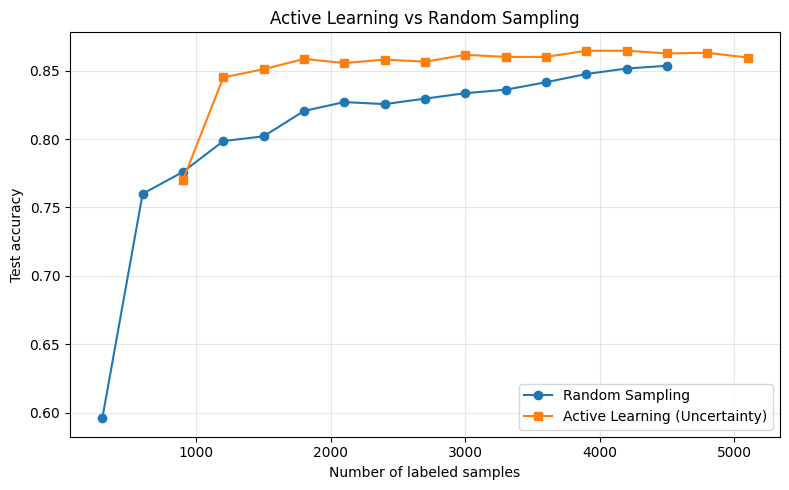

In [ ]:
"""
Active Learning vs Random Sampling — Baseline Experiment
==========================================================
Compares how much labeled data is needed to reach a target accuracy
using (1) random sampling and (2) uncertainty-based active learning.

Dataset: AG News (4-class news topic classification)
Model:   TF-IDF + Logistic Regression (fast, CPU-only, good first baseline)

Run:
    python al_experiment.py

Output:
    - learning_curve.png  (accuracy vs. number of labeled samples)
    - results.csv          (raw numbers for both strategies)
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


def load_ag_news(max_train=6000, max_test=2000):
    """
    Loads AG News via Hugging Face `datasets`.
    Falls back to a small synthetic dataset if there's no internet
    access (e.g. running in a sandboxed environment) — this lets you
    verify the pipeline logic works before running for real.
    """
    try:
        from datasets import load_dataset
        ds = load_dataset("fancyzhx/ag_news")
        train_texts = ds["train"]["text"][:max_train]
        train_labels = ds["train"]["label"][:max_train]
        test_texts = ds["test"]["text"][:max_test]
        test_labels = ds["test"]["label"][:max_test]
        print(f"Loaded real AG News: {len(train_texts)} train / {len(test_texts)} test")
        return train_texts, train_labels, test_texts, test_labels
    except Exception as e:
        print(f"[!] Could not download AG News ({e}).")
        print("[!] Falling back to SYNTHETIC data so you can test the pipeline offline.")
        print("[!] Run this script on your own machine / Colab with internet for real results.\n")
        return generate_synthetic_dataset(max_train, max_test)


def generate_synthetic_dataset(n_train, n_test):
    """Small synthetic 4-class text dataset, only used when AG News is unreachable."""
    topics = {
        0: ["stock market rises", "company earnings report", "economy grows this quarter", "bank interest rates"],
        1: ["team wins championship", "player scores goal", "olympic athlete trains", "football match tonight"],
        2: ["new smartphone released", "software update improves", "tech company launches product", "computer chip design"],
        3: ["election results announced", "government passes law", "president gives speech", "international summit held"],
    }
    def sample(n):
        texts, labels = [], []
        for _ in range(n):
            label = np.random.randint(0, 4)
            base = np.random.choice(topics[label])
            noise = " ".join(np.random.choice(
                ["today", "yesterday", "reports say", "officials confirm", "sources indicate"], size=2))
            texts.append(f"{base} {noise}")
            labels.append(label)
        return texts, labels
    train_texts, train_labels = sample(n_train)
    test_texts, test_labels = sample(n_test)
    return train_texts, train_labels, test_texts, test_labels


def vectorize(train_texts, test_texts):
    vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    return X_train, X_test


def run_random_sampling(X_train, y_train, X_test, y_test, batch_size, n_rounds):
    """Baseline: label random batches, retrain, track accuracy."""
    n_total = X_train.shape[0]
    all_idx = np.arange(n_total)
    np.random.shuffle(all_idx)

    labeled_idx = []
    accuracies, labels_used = [], []

    for r in range(n_rounds):
        new_idx = all_idx[r * batch_size:(r + 1) * batch_size]
        if len(new_idx) == 0:
            break
        labeled_idx.extend(new_idx)

        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train[labeled_idx], np.array(y_train)[labeled_idx])
        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)

        accuracies.append(acc)
        labels_used.append(len(labeled_idx))

    return labels_used, accuracies


def run_uncertainty_sampling(X_train, y_train, X_test, y_test, batch_size, n_rounds, seed_size=None):
    """Active learning: after each round, label the samples the model is LEAST confident about."""
    n_total = X_train.shape[0]
    seed_size = seed_size or batch_size

    all_idx = np.arange(n_total)
    np.random.shuffle(all_idx)
    labeled_idx = list(all_idx[:seed_size])
    unlabeled_idx = list(all_idx[seed_size:])

    accuracies, labels_used = [], []

    for r in range(n_rounds):
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train[labeled_idx], np.array(y_train)[labeled_idx])

        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        accuracies.append(acc)
        labels_used.append(len(labeled_idx))

        if not unlabeled_idx:
            break

        # Uncertainty = 1 - max predicted probability (least-confidence sampling)
        probs = clf.predict_proba(X_train[unlabeled_idx])
        uncertainty = 1 - probs.max(axis=1)
        n_pick = min(batch_size, len(unlabeled_idx))
        pick_order = np.argsort(-uncertainty)[:n_pick]  # most uncertain first

        pick_idx = [unlabeled_idx[i] for i in pick_order]
        labeled_idx.extend(pick_idx)
        unlabeled_idx = [i for i in unlabeled_idx if i not in set(pick_idx)]

    return labels_used, accuracies


def main():
    train_texts, train_labels, test_texts, test_labels = load_ag_news()
    X_train, X_test = vectorize(train_texts, test_texts)

    batch_size = max(50, X_train.shape[0] // 20)
    n_rounds = 15
    # Bigger seed set for AL avoids the "cold start" problem: with too few
    # initial labels, uncertainty estimates are unreliable and AL can pick
    # noisy samples early on. 3x batch_size gives the model a stable footing.
    seed_size = batch_size * 3

    print("Running random sampling baseline...")
    rand_labels, rand_acc = run_random_sampling(
        X_train, train_labels, X_test, test_labels, batch_size, n_rounds)

    print("Running uncertainty-sampling active learning...")
    al_labels, al_acc = run_uncertainty_sampling(
        X_train, train_labels, X_test, test_labels, batch_size, n_rounds, seed_size=seed_size)

    # Save results
    results = pd.DataFrame({
        "labels_used_random": pd.Series(rand_labels),
        "accuracy_random": pd.Series(rand_acc),
        "labels_used_al": pd.Series(al_labels),
        "accuracy_al": pd.Series(al_acc),
    })
    results.to_csv("results.csv", index=False)
    print("\nSaved raw results to results.csv")

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(rand_labels, rand_acc, marker="o", label="Random Sampling")
    plt.plot(al_labels, al_acc, marker="s", label="Active Learning (Uncertainty)")
    plt.xlabel("Number of labeled samples")
    plt.ylabel("Test accuracy")
    plt.title("Active Learning vs Random Sampling")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("learning_curve.png", dpi=150)
    print("Saved plot to learning_curve.png")

    # --- Metric 1: accuracy at matched label budgets (most honest comparison) ---
    print("\nAccuracy at matched label budgets:")
    print(f"{'Labels':>8} | {'Random':>8} | {'Active Learning':>16}")
    common_budgets = sorted(set(rand_labels) & set(al_labels))
    for b in common_budgets:
        r = rand_acc[rand_labels.index(b)]
        a = al_acc[al_labels.index(b)]
        print(f"{b:>8} | {r:>8.2%} | {a:>16.2%}")

    # --- Metric 2: labels needed to reach a target near the plateau, not the ---
    # ---            cold-start dip, so pick a target close to peak accuracy ---
    peak = max(max(rand_acc), max(al_acc))
    target = 0.98 * peak
    rand_needed = next((l for l, a in zip(rand_labels, rand_acc) if a >= target), None)
    al_needed = next((l for l, a in zip(al_labels, al_acc) if a >= target), None)
    print(f"\nLabels needed to reach {target:.2%} accuracy (98% of peak {peak:.2%}):")
    print(f"  Random sampling:   {rand_needed}")
    print(f"  Active learning:   {al_needed}")
    if rand_needed and al_needed:
        savings = (1 - al_needed / rand_needed) * 100
        print(f"  --> Annotation savings: {savings:.1f}%")
    else:
        print("  --> One strategy never reached this target within the tested budget;"
              " try more rounds (increase n_rounds) for a cleaner comparison.")


if __name__ == "__main__":
    main()


Loaded real AG News: 6000 train / 2000 test
Simulated cost per sample: min=1.22, max=3.68, mean=1.78

=== Seed 1/5 ===

Diagnostic: correlation between cost and uncertainty = -0.099
  --> Cost and informativeness are roughly UNCORRELATED.
      Cost-aware selection should be close to a free efficiency gain.

=== Seed 2/5 ===

Diagnostic: correlation between cost and uncertainty = -0.107
  --> Cost and informativeness are roughly UNCORRELATED.
      Cost-aware selection should be close to a free efficiency gain.

=== Seed 3/5 ===

Diagnostic: correlation between cost and uncertainty = -0.105
  --> Cost and informativeness are roughly UNCORRELATED.
      Cost-aware selection should be close to a free efficiency gain.

=== Seed 4/5 ===

Diagnostic: correlation between cost and uncertainty = -0.110
  --> Cost and informativeness are roughly UNCORRELATED.
      Cost-aware selection should be close to a free efficiency gain.

=== Seed 5/5 ===

Diagnostic: correlation between cost and uncerta

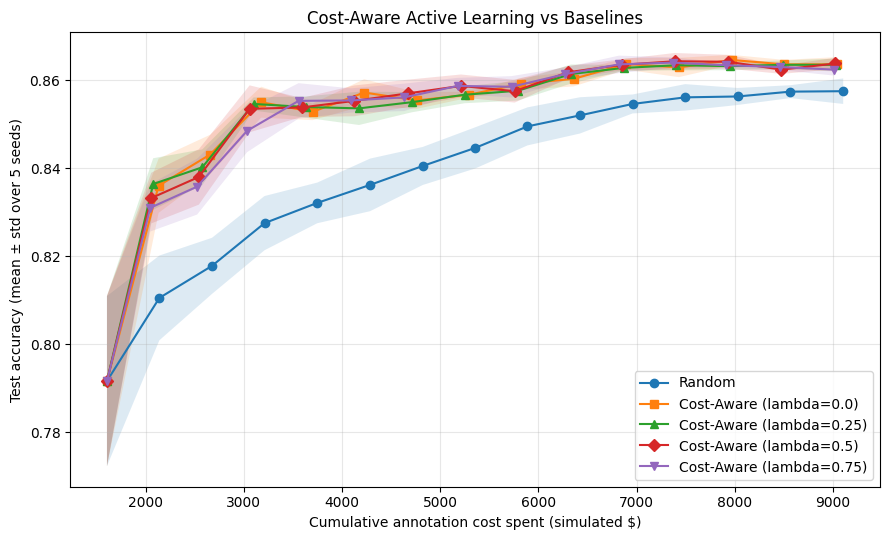

In [ ]:
"""
Cost-Aware Active Learning — Extension of al_experiment.py
=============================================================
Adds a third strategy: COST-AWARE active learning, which selects samples
by uncertainty-per-dollar rather than raw uncertainty. This is the core
novel contribution for the paper: most AL research optimizes accuracy per
LABEL, but real annotation budgets are measured in MONEY, and not all
samples cost the same to label.

Cost model (simulated, documented assumption for the paper):
    cost(sample) = BASE_COST + LENGTH_FACTOR * (number of words in the text)
    Rationale: longer articles take an annotator longer to read and judge,
    so they cost more to label. This is a standard, defensible proxy used
    in annotation-cost literature when real per-sample cost logs aren't
    available.

Three strategies compared, all plotted against CUMULATIVE COST SPENT
(not just label count) on the x-axis:
    1. Random sampling
    2. Uncertainty sampling (ignores cost)
    3. Cost-aware sampling (uncertainty / cost ratio)

Run:
    python al_cost_aware.py

Output:
    - cost_aware_curve.png
    - cost_aware_results.csv
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

BASE_COST = 1.0        # flat cost per sample (e.g. minimum annotator time)
LENGTH_FACTOR = 0.02    # extra cost per word


def load_ag_news(max_train=6000, max_test=2000):
    try:
        from datasets import load_dataset
        ds = load_dataset("fancyzhx/ag_news")
        train_texts = ds["train"]["text"][:max_train]
        train_labels = ds["train"]["label"][:max_train]
        test_texts = ds["test"]["text"][:max_test]
        test_labels = ds["test"]["label"][:max_test]
        print(f"Loaded real AG News: {len(train_texts)} train / {len(test_texts)} test")
        return train_texts, train_labels, test_texts, test_labels
    except Exception as e:
        print(f"[!] Could not download AG News ({e}).")
        print("[!] Falling back to SYNTHETIC data so you can test the pipeline offline.")
        print("[!] Run this script on your own machine / Colab with internet for real results.\n")
        return generate_synthetic_dataset(max_train, max_test)


def generate_synthetic_dataset(n_train, n_test):
    topics = {
        0: ["stock market rises", "company earnings report", "economy grows this quarter", "bank interest rates"],
        1: ["team wins championship", "player scores goal", "olympic athlete trains", "football match tonight"],
        2: ["new smartphone released", "software update improves", "tech company launches product", "computer chip design"],
        3: ["election results announced", "government passes law", "president gives speech", "international summit held"],
    }
    def sample(n):
        texts, labels = [], []
        for _ in range(n):
            label = np.random.randint(0, 4)
            base = np.random.choice(topics[label])
            noise = " ".join(np.random.choice(
                ["today", "yesterday", "reports say", "officials confirm", "sources indicate"],
                size=np.random.randint(1, 8)))
            texts.append(f"{base} {noise}")
            labels.append(label)
        return texts, labels
    train_texts, train_labels = sample(n_train)
    test_texts, test_labels = sample(n_test)
    return train_texts, train_labels, test_texts, test_labels


def compute_costs(texts):
    """Simulated per-sample labeling cost based on text length."""
    return np.array([BASE_COST + LENGTH_FACTOR * len(t.split()) for t in texts])


def vectorize(train_texts, test_texts):
    vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    return X_train, X_test


def run_strategy(X_train, y_train, X_test, y_test, costs, batch_size, n_rounds,
                  seed_size, strategy="random", cost_lambda=1.0):
    """
    Unified loop for all three strategies.
    strategy: "random" | "uncertainty" | "cost_aware"
    cost_lambda: exponent controlling how strongly cost is penalized in
        cost_aware scoring: score = uncertainty / (cost ** cost_lambda).
        lambda=0 reduces to plain uncertainty sampling (cost ignored).
        lambda=1 is a full cost-per-dollar tradeoff (can overcorrect if
        cost correlates with informativeness, as AG News shows).
    Tracks cumulative COST spent, not just label count.
    """
    n_total = X_train.shape[0]
    all_idx = np.arange(n_total)
    np.random.shuffle(all_idx)

    labeled_idx = list(all_idx[:seed_size])
    unlabeled_idx = list(all_idx[seed_size:])

    accuracies, cum_cost, n_labels = [], [], []
    total_cost = costs[labeled_idx].sum()

    for r in range(n_rounds):
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train[labeled_idx], np.array(y_train)[labeled_idx])

        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        accuracies.append(acc)
        cum_cost.append(total_cost)
        n_labels.append(len(labeled_idx))

        if not unlabeled_idx:
            break

        if strategy == "random":
            n_pick = min(batch_size, len(unlabeled_idx))
            pick_idx = list(np.random.choice(unlabeled_idx, size=n_pick, replace=False))

        else:
            probs = clf.predict_proba(X_train[unlabeled_idx])
            uncertainty = 1 - probs.max(axis=1)

            if strategy == "uncertainty":
                score = uncertainty
            elif strategy == "cost_aware":
                # Value = uncertainty per unit cost, with a tunable exponent.
                # lambda controls how aggressively cost is penalized.
                sample_costs = costs[unlabeled_idx]
                score = uncertainty / np.power(sample_costs, cost_lambda)
            else:
                raise ValueError(f"Unknown strategy: {strategy}")

            n_pick = min(batch_size, len(unlabeled_idx))
            order = np.argsort(-score)[:n_pick]
            pick_idx = [unlabeled_idx[i] for i in order]

        labeled_idx.extend(pick_idx)
        total_cost += costs[pick_idx].sum()
        pick_set = set(pick_idx)
        unlabeled_idx = [i for i in unlabeled_idx if i not in pick_set]

    return cum_cost, accuracies, n_labels


def diagnose_cost_informativeness_correlation(X_train, y_train, costs, seed_size):
    """
    Checks whether cost (text length) correlates with informativeness
    (uncertainty). If they're positively correlated, naive cost-weighting
    will systematically avoid the most useful samples -- explaining why
    cost-aware can underperform plain uncertainty sampling.
    """
    idx = np.arange(X_train.shape[0])
    np.random.shuffle(idx)
    seed_idx = list(idx[:seed_size])
    rest_idx = list(idx[seed_size:])

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train[seed_idx], np.array(y_train)[seed_idx])
    probs = clf.predict_proba(X_train[rest_idx])
    uncertainty = 1 - probs.max(axis=1)

    corr = np.corrcoef(costs[rest_idx], uncertainty)[0, 1]
    print(f"\nDiagnostic: correlation between cost and uncertainty = {corr:.3f}")
    if corr > 0.15:
        print("  --> Cost and informativeness are POSITIVELY correlated:")
        print("      expensive samples tend to be more informative.")
        print("      This explains why naive cost-weighting can hurt accuracy-per-dollar.")
    elif corr < -0.15:
        print("  --> Cost and informativeness are NEGATIVELY correlated:")
        print("      cheap samples tend to be more informative -- cost-aware")
        print("      selection should help here.")
    else:
        print("  --> Cost and informativeness are roughly UNCORRELATED.")
        print("      Cost-aware selection should be close to a free efficiency gain.")
    return corr


def main():
    train_texts, train_labels, test_texts, test_labels = load_ag_news()
    X_train, X_test = vectorize(train_texts, test_texts)
    costs = compute_costs(train_texts)

    print(f"Simulated cost per sample: min={costs.min():.2f}, "
          f"max={costs.max():.2f}, mean={costs.mean():.2f}")

    batch_size = max(50, X_train.shape[0] // 20)
    n_rounds = 15
    seed_size = batch_size * 3
    N_SEEDS = 5  # number of random seeds to average over -- increase for
                 # a tighter estimate, at the cost of runtime.

    strategies = {
        "Random": ("random", None),
        "Cost-Aware (lambda=0.0)": ("cost_aware", 0.0),   # = plain uncertainty sampling
        "Cost-Aware (lambda=0.25)": ("cost_aware", 0.25),
        "Cost-Aware (lambda=0.5)": ("cost_aware", 0.5),
        "Cost-Aware (lambda=0.75)": ("cost_aware", 0.75),
        "Cost-Aware (lambda=1.0)": ("cost_aware", 1.0),
    }

    # results[name] = list of (cum_cost, accuracy) arrays, one pair per seed
    raw_runs = {name: [] for name in strategies}
    correlations = []

    for seed in range(N_SEEDS):
        print(f"\n=== Seed {seed + 1}/{N_SEEDS} ===")
        np.random.seed(RANDOM_SEED + seed)

        corr = diagnose_cost_informativeness_correlation(X_train, train_labels, costs, seed_size)
        correlations.append(corr)

        for name, (strat, lam) in strategies.items():
            np.random.seed(RANDOM_SEED + seed)  # reset so every strategy sees the SAME seed data
            kwargs = {"cost_lambda": lam} if lam is not None else {}
            cum_cost, acc, n_labels = run_strategy(
                X_train, train_labels, X_test, test_labels, costs,
                batch_size, n_rounds, seed_size, strategy=strat, **kwargs)
            raw_runs[name].append((np.array(cum_cost), np.array(acc)))

    print(f"\nMean cost/uncertainty correlation across seeds: "
          f"{np.mean(correlations):.3f} (std {np.std(correlations):.3f})")

    # Aggregate: align by ROUND INDEX (not exact cost, which varies slightly
    # per seed), then average accuracy and cost across seeds at each round.
    aggregated = {}
    for name, runs in raw_runs.items():
        min_len = min(len(acc) for _, acc in runs)
        accs = np.array([acc[:min_len] for _, acc in runs])
        costs_arr = np.array([c[:min_len] for c, _ in runs])
        aggregated[name] = {
            "cost_mean": costs_arr.mean(axis=0),
            "acc_mean": accs.mean(axis=0),
            "acc_std": accs.std(axis=0),
        }

    # Save raw results
    df_dict = {}
    for name, v in aggregated.items():
        key = "".join(c if c.isalnum() else "_" for c in name)
        df_dict[f"cost_{key}"] = pd.Series(v["cost_mean"])
        df_dict[f"accuracy_mean_{key}"] = pd.Series(v["acc_mean"])
        df_dict[f"accuracy_std_{key}"] = pd.Series(v["acc_std"])
    pd.DataFrame(df_dict).to_csv("cost_aware_results.csv", index=False)
    print("\nSaved raw results to cost_aware_results.csv")

    # Plot: accuracy vs cumulative cost spent, with shaded std band
    plt.figure(figsize=(9, 5.5))
    markers = ["o", "s", "^", "D", "v"]
    for (name, v), m in zip(aggregated.items(), markers):
        plt.plot(v["cost_mean"], v["acc_mean"], marker=m, label=name)
        plt.fill_between(v["cost_mean"], v["acc_mean"] - v["acc_std"],
                          v["acc_mean"] + v["acc_std"], alpha=0.15)
    plt.xlabel("Cumulative annotation cost spent (simulated $)")
    plt.ylabel("Test accuracy (mean \u00b1 std over {} seeds)".format(N_SEEDS))
    plt.title("Cost-Aware Active Learning vs Baselines")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("cost_aware_curve.png", dpi=150)
    print("Saved plot to cost_aware_curve.png")

    # Headline metric: cost needed to reach a near-peak accuracy target,
    # computed on the AVERAGED curves -- much more trustworthy than one run.
    peak = max(v["acc_mean"].max() for v in aggregated.values())
    target = 0.98 * peak
    print(f"\nCost needed to reach {target:.2%} accuracy (98% of peak {peak:.2%}), averaged over {N_SEEDS} seeds:")
    cost_needed = {}
    for name, v in aggregated.items():
        needed = next((c for c, a in zip(v["cost_mean"], v["acc_mean"]) if a >= target), None)
        cost_needed[name] = needed
        print(f"  {name:<28}: {needed}")

    baseline = cost_needed.get("Random")
    uncertainty_cost = cost_needed.get("Cost-Aware (lambda=0.0)")  # = plain uncertainty sampling
    print()
    for name, needed in cost_needed.items():
        if name == "Random" or needed is None or baseline is None:
            continue
        savings_vs_random = (1 - needed / baseline) * 100
        print(f"--> {name} saves {savings_vs_random:.1f}% of budget vs random (avg of {N_SEEDS} seeds)")
        if uncertainty_cost is not None and name != "Cost-Aware (lambda=0.0)":
            savings_vs_uncertainty = (1 - needed / uncertainty_cost) * 100
            print(f"    and {savings_vs_uncertainty:.1f}% vs plain uncertainty sampling (lambda=0.0)")

    # Best lambda summary -- the actual headline for the paper's ablation section
    best_name = min(
        (n for n in cost_needed if n != "Random" and cost_needed[n] is not None),
        key=lambda n: cost_needed[n],
        default=None,
    )
    if best_name:
        print(f"\nBest strategy: {best_name} (lowest cost to reach target accuracy)")


if __name__ == "__main__":
    main()

=== Loading AG News (source domain) ===
Loaded real fancyzhx/ag_news: 6000 train / 2000 test (classes present in train: [0, 1, 2, 3])

=== Loading IMDB (target domain) ===
Loaded real stanfordnlp/imdb: 6000 train / 2000 test (classes present in train: [0, 1])

=== Running strategies on AG News ===
Diagnostic: cost/uncertainty correlation = -0.113, cost std = 0.197, cost range = 2.720

[AG News] Cost needed to reach 86.85% accuracy (98% of peak 88.62%):
  Random                      : 5792.664
  Uncertainty (lambda=0.0)    : 3658.1600000000008
  Cost-Aware (lambda=0.75)    : 4065.3719999999994
  --> Uncertainty (lambda=0.0) saves 36.8% of budget vs random on AG News
  --> Cost-Aware (lambda=0.75) saves 29.8% of budget vs random on AG News

=== Running strategies on IMDB ===
Diagnostic: cost/uncertainty correlation = 0.096, cost std = 0.927, cost range = 3.760

[IMDB] Cost needed to reach 81.93% accuracy (98% of peak 83.60%):
  Random                      : 12543.232
  Uncertainty (lambd

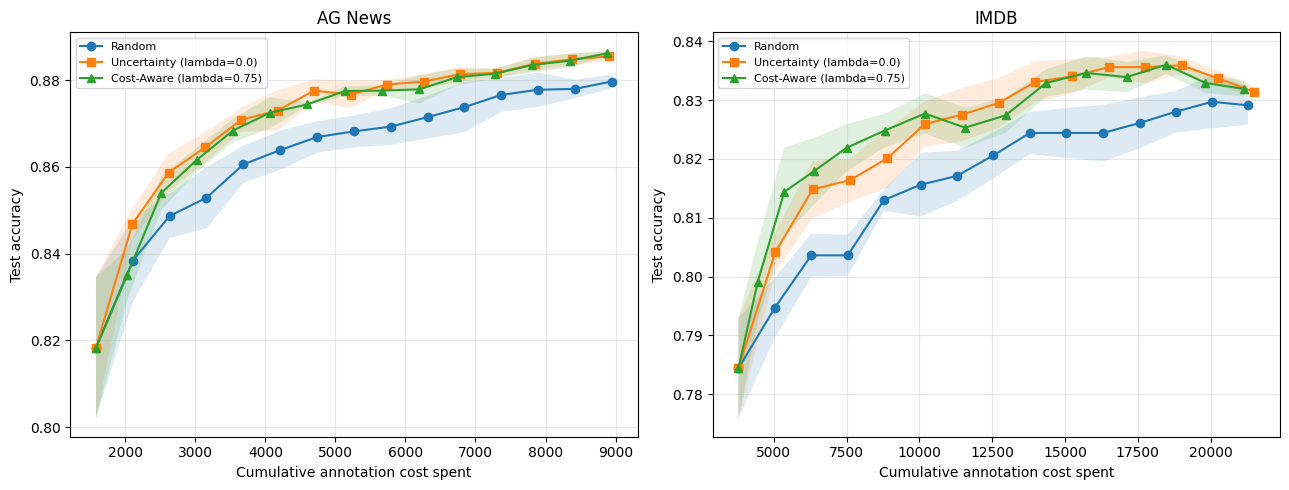

In [ ]:
"""
Domain-Transfer Generalization Test — Extension of al_cost_aware.py
=======================================================================
Tests whether the cost-aware active learning strategy that worked well on
AG News (news topic classification) ALSO works well on a different domain:
IMDB (movie review sentiment classification).

This is the "generalization" research angle: does an AL strategy tuned on
one domain transfer to another, or is it dataset-specific? We do NOT
transfer the trained classifier itself (the label spaces are different --
4-class topics vs 2-class sentiment). Instead we test whether the SAME
acquisition strategy and lambda value (found on AG News) gives a similar
efficiency advantage when applied fresh to IMDB.

Three strategies, run independently on both domains:
    1. Random sampling
    2. Uncertainty sampling (lambda=0.0)
    3. Cost-Aware sampling (lambda=0.75 -- the winner found on AG News)

Run:
    python al_domain_transfer.py

Output:
    - domain_transfer_curve.png  (side-by-side panels: AG News vs IMDB)
    - domain_transfer_results.csv
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

RANDOM_SEED = 42

BASE_COST = 1.0
LENGTH_FACTOR = 0.02

BEST_LAMBDA = 0.75  # winner found on AG News -- the value being tested for transfer
N_SEEDS = 5
N_ROUNDS = 15
MAX_TRAIN = 6000
MAX_TEST = 2000


def load_dataset_safe(hf_name, text_field="text", label_field="label",
                       max_train=MAX_TRAIN, max_test=MAX_TEST, max_words=200):
    """
    Loads a Hugging Face dataset. Falls back to synthetic data if offline.
    max_words: truncate long texts (e.g. IMDB reviews) for speed -- doesn't
    change the classification task, just keeps TF-IDF/training fast.
    """
    try:
        from datasets import load_dataset
        ds = load_dataset(hf_name)
        # IMPORTANT: some HF datasets (notably IMDB) are stored in label-sorted
        # order (all negative reviews first, then all positive). Slicing the
        # first N rows without shuffling can grab only one class. Always
        # shuffle before taking a subset.
        train_split = ds["train"].shuffle(seed=RANDOM_SEED)
        test_split = ds["test"].shuffle(seed=RANDOM_SEED)

        def clip(texts):
            return [" ".join(t.split()[:max_words]) for t in texts]

        train_texts = clip(train_split[text_field][:max_train])
        train_labels = train_split[label_field][:max_train]
        test_texts = clip(test_split[text_field][:max_test])
        test_labels = test_split[label_field][:max_test]
        print(f"Loaded real {hf_name}: {len(train_texts)} train / {len(test_texts)} test "
              f"(classes present in train: {sorted(set(train_labels))})")
        return train_texts, train_labels, test_texts, test_labels
    except Exception as e:
        print(f"[!] Could not download {hf_name} ({e}).")
        print("[!] Falling back to SYNTHETIC data so you can test the pipeline offline.")
        print("[!] Run this script on your own machine / Colab with internet for real results.\n")
        return generate_synthetic_dataset(max_train, max_test)


def generate_synthetic_dataset(n_train, n_test, n_classes=2):
    vocab = {
        0: ["boring slow disappointing", "waste of time", "poorly written weak plot"],
        1: ["brilliant amazing loved it", "fantastic performance", "highly recommend great film"],
    }
    def sample(n):
        texts, labels = [], []
        for _ in range(n):
            label = np.random.randint(0, n_classes)
            base = np.random.choice(vocab[label])
            noise = " ".join(np.random.choice(
                ["really", "honestly", "overall", "in my opinion", "definitely"],
                size=np.random.randint(1, 10)))
            texts.append(f"{base} {noise}")
            labels.append(label)
        return texts, labels
    train_texts, train_labels = sample(n_train)
    test_texts, test_labels = sample(n_test)
    return train_texts, train_labels, test_texts, test_labels


def compute_costs(texts):
    return np.array([BASE_COST + LENGTH_FACTOR * len(t.split()) for t in texts])


def diagnose_cost_informativeness_correlation(X_train, y_train, costs, seed_size):
    """Same diagnostic as al_cost_aware.py: checks whether cost (text length)
    correlates with informativeness (uncertainty). Run per-domain here so we
    can compare AG News vs IMDB directly."""
    idx = np.arange(X_train.shape[0])
    np.random.shuffle(idx)
    seed_idx = list(idx[:seed_size])
    rest_idx = list(idx[seed_size:])

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train[seed_idx], np.array(y_train)[seed_idx])
    probs = clf.predict_proba(X_train[rest_idx])
    uncertainty = 1 - probs.max(axis=1)

    corr = np.corrcoef(costs[rest_idx], uncertainty)[0, 1]
    cost_std = costs[rest_idx].std()
    cost_range = costs[rest_idx].max() - costs[rest_idx].min()
    print(f"Diagnostic: cost/uncertainty correlation = {corr:.3f}, "
          f"cost std = {cost_std:.3f}, cost range = {cost_range:.3f}")
    return corr, cost_std


def vectorize(train_texts, test_texts):
    vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    return X_train, X_test


def run_strategy(X_train, y_train, X_test, y_test, costs, batch_size, n_rounds,
                  seed_size, strategy="random", cost_lambda=None):
    n_total = X_train.shape[0]
    all_idx = np.arange(n_total)
    np.random.shuffle(all_idx)

    labeled_idx = list(all_idx[:seed_size])
    unlabeled_idx = list(all_idx[seed_size:])

    accuracies, cum_cost = [], []
    total_cost = costs[labeled_idx].sum()

    for r in range(n_rounds):
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train[labeled_idx], np.array(y_train)[labeled_idx])

        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        accuracies.append(acc)
        cum_cost.append(total_cost)

        if not unlabeled_idx:
            break

        if strategy == "random":
            n_pick = min(batch_size, len(unlabeled_idx))
            pick_idx = list(np.random.choice(unlabeled_idx, size=n_pick, replace=False))
        else:
            probs = clf.predict_proba(X_train[unlabeled_idx])
            uncertainty = 1 - probs.max(axis=1)
            if cost_lambda:
                sample_costs = costs[unlabeled_idx]
                score = uncertainty / np.power(sample_costs, cost_lambda)
            else:
                score = uncertainty
            n_pick = min(batch_size, len(unlabeled_idx))
            order = np.argsort(-score)[:n_pick]
            pick_idx = [unlabeled_idx[i] for i in order]

        labeled_idx.extend(pick_idx)
        total_cost += costs[pick_idx].sum()
        pick_set = set(pick_idx)
        unlabeled_idx = [i for i in unlabeled_idx if i not in pick_set]

    return cum_cost, accuracies


def run_domain(name, train_texts, train_labels, test_texts, test_labels):
    """Runs all 3 strategies across N_SEEDS on one domain, returns aggregated results."""
    X_train, X_test = vectorize(train_texts, test_texts)
    costs = compute_costs(train_texts)
    batch_size = max(50, X_train.shape[0] // 20)
    seed_size = batch_size * 3

    # Diagnose cost/informativeness relationship for this domain -- explains
    # WHY cost-aware sampling might help more or less here than elsewhere.
    diagnose_cost_informativeness_correlation(X_train, train_labels, costs, seed_size)

    strategies = {
        "Random": ("random", None),
        "Uncertainty (lambda=0.0)": ("uncertainty", None),
        f"Cost-Aware (lambda={BEST_LAMBDA})": ("uncertainty", BEST_LAMBDA),
    }

    raw_runs = {s: [] for s in strategies}
    for seed in range(N_SEEDS):
        for sname, (strat, lam) in strategies.items():
            np.random.seed(RANDOM_SEED + seed)
            cum_cost, acc = run_strategy(
                X_train, train_labels, X_test, test_labels, costs,
                batch_size, N_ROUNDS, seed_size, strategy=strat, cost_lambda=lam)
            raw_runs[sname].append((np.array(cum_cost), np.array(acc)))

    aggregated = {}
    for sname, runs in raw_runs.items():
        min_len = min(len(a) for _, a in runs)
        accs = np.array([a[:min_len] for _, a in runs])
        costs_arr = np.array([c[:min_len] for c, _ in runs])
        aggregated[sname] = {
            "cost_mean": costs_arr.mean(axis=0),
            "acc_mean": accs.mean(axis=0),
            "acc_std": accs.std(axis=0),
        }

    # Savings vs random at 98%-of-peak target
    peak = max(v["acc_mean"].max() for v in aggregated.values())
    target = 0.98 * peak
    cost_needed = {}
    for sname, v in aggregated.items():
        needed = next((c for c, a in zip(v["cost_mean"], v["acc_mean"]) if a >= target), None)
        cost_needed[sname] = needed

    print(f"\n[{name}] Cost needed to reach {target:.2%} accuracy (98% of peak {peak:.2%}):")
    for sname, needed in cost_needed.items():
        print(f"  {sname:<28}: {needed}")
    baseline = cost_needed.get("Random")
    if baseline:
        for sname, needed in cost_needed.items():
            if sname == "Random" or needed is None:
                continue
            savings = (1 - needed / baseline) * 100
            print(f"  --> {sname} saves {savings:.1f}% of budget vs random on {name}")

    return aggregated, cost_needed


def main():
    print("=== Loading AG News (source domain) ===")
    ag_train_t, ag_train_l, ag_test_t, ag_test_l = load_dataset_safe("fancyzhx/ag_news")

    print("\n=== Loading IMDB (target domain) ===")
    imdb_train_t, imdb_train_l, imdb_test_t, imdb_test_l = load_dataset_safe("stanfordnlp/imdb")

    print("\n=== Running strategies on AG News ===")
    ag_results, ag_cost_needed = run_domain("AG News", ag_train_t, ag_train_l, ag_test_t, ag_test_l)

    print("\n=== Running strategies on IMDB ===")
    imdb_results, imdb_cost_needed = run_domain("IMDB", imdb_train_t, imdb_train_l, imdb_test_t, imdb_test_l)

    # Side-by-side plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, (domain_name, results) in zip(axes, [("AG News", ag_results), ("IMDB", imdb_results)]):
        markers = ["o", "s", "^"]
        for (sname, v), m in zip(results.items(), markers):
            ax.plot(v["cost_mean"], v["acc_mean"], marker=m, label=sname)
            ax.fill_between(v["cost_mean"], v["acc_mean"] - v["acc_std"],
                             v["acc_mean"] + v["acc_std"], alpha=0.15)
        ax.set_xlabel("Cumulative annotation cost spent")
        ax.set_ylabel("Test accuracy")
        ax.set_title(domain_name)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("domain_transfer_curve.png", dpi=150)
    print("\nSaved plot to domain_transfer_curve.png")

    # Save CSV
    df_dict = {}
    for domain_name, results in [("AGNews", ag_results), ("IMDB", imdb_results)]:
        for sname, v in results.items():
            key = "".join(c if c.isalnum() else "_" for c in f"{domain_name}_{sname}")
            df_dict[f"cost_{key}"] = pd.Series(v["cost_mean"])
            df_dict[f"acc_{key}"] = pd.Series(v["acc_mean"])
    pd.DataFrame(df_dict).to_csv("domain_transfer_results.csv", index=False)
    print("Saved raw results to domain_transfer_results.csv")

    # Final generalization verdict
    print("\n=== GENERALIZATION SUMMARY ===")
    ag_baseline = ag_cost_needed.get("Random")
    imdb_baseline = imdb_cost_needed.get("Random")
    cost_key = f"Cost-Aware (lambda={BEST_LAMBDA})"
    ag_cost_aware = ag_cost_needed.get(cost_key)
    imdb_cost_aware = imdb_cost_needed.get(cost_key)
    if ag_baseline and ag_cost_aware:
        ag_savings = (1 - ag_cost_aware / ag_baseline) * 100
        print(f"AG News: cost-aware (lambda={BEST_LAMBDA}) saves {ag_savings:.1f}% vs random")
    if imdb_baseline and imdb_cost_aware:
        imdb_savings = (1 - imdb_cost_aware / imdb_baseline) * 100
        print(f"IMDB:    cost-aware (lambda={BEST_LAMBDA}) saves {imdb_savings:.1f}% vs random")
    print("\nIf both savings numbers are in a similar range, the strategy generalizes.")
    print("If IMDB's savings are much lower (or negative), the AG News-tuned lambda")
    print("is domain-specific and would need re-tuning per domain -- also a valid finding.")


if __name__ == "__main__":
    main()

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Loaded real stanfordnlp/imdb: 6000 train / 2000 test (classes present in train: [0, 1])

=== [IMDB] Seed 1/5 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

=== [IMDB] Seed 2/5 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

=== [IMDB] Seed 3/5 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

=== [IMDB] Seed 4/5 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

=== [IMDB] Seed 5/5 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

[IMDB] Cost needed to reach 81.93% accuracy (98% of peak

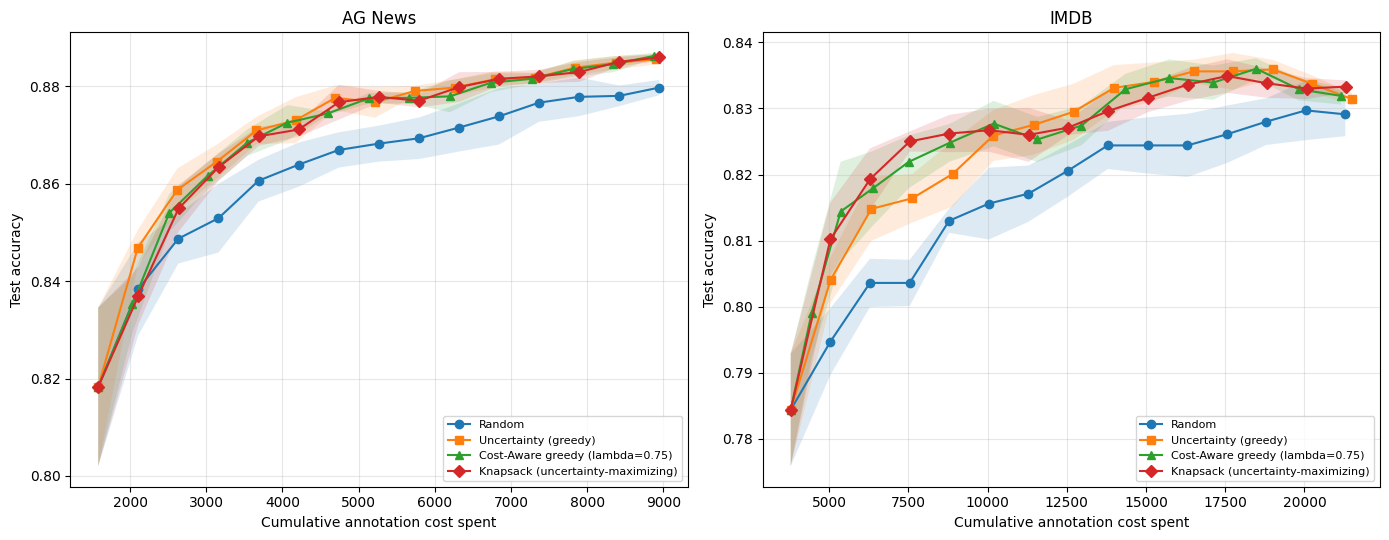

In [ ]:
"""
Knapsack-Based Active Learning vs. Greedy Cost-Aware Ranking
=================================================================
Tests the core idea behind KnapsackBALD (Dossou et al., 2026): instead of
greedily ranking unlabeled samples by a score (uncertainty/cost^lambda) and
taking the top-k, solve an actual 0-1 KNAPSACK problem each round: choose the
SUBSET of candidate samples that maximizes total uncertainty subject to a
cost budget. This can find better subsets than greedy ranking, because greedy
ranking can't "trade off" -- e.g. it might miss a combination of two cheaper,
almost-as-informative samples that together beat one expensive, slightly-more
informative one.

This does NOT reimplement full KnapsackBALD (no Bayesian/BatchBALD mutual
information estimation) -- it isolates and tests only the KNAPSACK
optimization half of their idea, using the same uncertainty scores as our
other experiments. This is an honest partial comparison, not a claim to
replicate their full method.

Four strategies compared:
    1. Random sampling
    2. Uncertainty sampling (greedy, ignores cost)
    3. Cost-Aware greedy (lambda=0.75 -- our best from earlier experiments)
    4. Knapsack (uncertainty-maximizing subset selection under a cost budget)

Run:
    python al_knapsack.py

Output:
    - knapsack_curve.png
    - knapsack_results.csv
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

RANDOM_SEED = 42

BASE_COST = 1.0
LENGTH_FACTOR = 0.02
BEST_LAMBDA = 0.75
N_SEEDS = 5
N_ROUNDS = 15
MAX_TRAIN = 6000
MAX_TEST = 2000

# Knapsack-specific settings
N_CANDIDATES_MULTIPLIER = 5  # restrict knapsack to top-K*batch_size most
                              # uncertain samples each round -- keeps the DP
                              # tractable (full-pool knapsack would be too slow)
COST_PRECISION = 10          # discretize cost to nearest 1/COST_PRECISION
                              # (0.1 units) so the DP has an integer capacity


def load_dataset_safe(hf_name, text_field="text", label_field="label",
                       max_train=MAX_TRAIN, max_test=MAX_TEST, max_words=200):
    try:
        from datasets import load_dataset
        ds = load_dataset(hf_name)
        train_split = ds["train"].shuffle(seed=RANDOM_SEED)
        test_split = ds["test"].shuffle(seed=RANDOM_SEED)

        def clip(texts):
            return [" ".join(t.split()[:max_words]) for t in texts]

        train_texts = clip(train_split[text_field][:max_train])
        train_labels = train_split[label_field][:max_train]
        test_texts = clip(test_split[text_field][:max_test])
        test_labels = test_split[label_field][:max_test]
        print(f"Loaded real {hf_name}: {len(train_texts)} train / {len(test_texts)} test "
              f"(classes present in train: {sorted(set(train_labels))})")
        return train_texts, train_labels, test_texts, test_labels
    except Exception as e:
        print(f"[!] Could not download {hf_name} ({e}).")
        print("[!] Falling back to SYNTHETIC data so you can test the pipeline offline.")
        print("[!] Run this script on your own machine / Colab with internet for real results.\n")
        return generate_synthetic_dataset(max_train, max_test)


def generate_synthetic_dataset(n_train, n_test):
    topics = {
        0: ["stock market rises", "company earnings report", "economy grows this quarter", "bank interest rates"],
        1: ["team wins championship", "player scores goal", "olympic athlete trains", "football match tonight"],
        2: ["new smartphone released", "software update improves", "tech company launches product", "computer chip design"],
        3: ["election results announced", "government passes law", "president gives speech", "international summit held"],
    }
    def sample(n):
        texts, labels = [], []
        for _ in range(n):
            label = np.random.randint(0, 4)
            base = np.random.choice(topics[label])
            noise = " ".join(np.random.choice(
                ["today", "yesterday", "reports say", "officials confirm", "sources indicate"],
                size=np.random.randint(1, 8)))
            texts.append(f"{base} {noise}")
            labels.append(label)
        return texts, labels
    train_texts, train_labels = sample(n_train)
    test_texts, test_labels = sample(n_test)
    return train_texts, train_labels, test_texts, test_labels


def compute_costs(texts):
    return np.array([BASE_COST + LENGTH_FACTOR * len(t.split()) for t in texts])


def vectorize(train_texts, test_texts):
    vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    return X_train, X_test


def solve_knapsack(values, costs, budget_units):
    """
    Standard 0-1 knapsack via dynamic programming (space-optimized, O(n*budget)).
    values: informativeness (uncertainty) of each candidate -- to maximize
    costs: integer cost of each candidate (already discretized)
    budget_units: integer total budget
    Returns: list of selected candidate indices (into the `values`/`costs` arrays).
    """
    n = len(values)
    # dp[c] = best total value achievable with total cost exactly <= c
    dp = np.zeros(budget_units + 1)
    # choice[i][c] = True if item i is taken in the optimal solution for budget c
    choice = np.zeros((n, budget_units + 1), dtype=bool)

    for i in range(n):
        c_i = costs[i]
        v_i = values[i]
        if c_i > budget_units:
            continue
        # iterate capacity backwards so each item is only used once (0-1 knapsack)
        for c in range(budget_units, c_i - 1, -1):
            candidate = dp[c - c_i] + v_i
            if candidate > dp[c]:
                dp[c] = candidate
                choice[i, c] = True

    # backtrack to find which items were selected
    selected = []
    c = budget_units
    for i in range(n - 1, -1, -1):
        if choice[i, c]:
            selected.append(i)
            c -= costs[i]
    return selected


def run_strategy(X_train, y_train, X_test, y_test, costs, batch_size, n_rounds,
                  seed_size, strategy="random", cost_lambda=None):
    n_total = X_train.shape[0]
    all_idx = np.arange(n_total)
    np.random.shuffle(all_idx)

    labeled_idx = list(all_idx[:seed_size])
    unlabeled_idx = list(all_idx[seed_size:])

    accuracies, cum_cost = [], []
    total_cost = costs[labeled_idx].sum()
    mean_cost = costs.mean()

    for r in range(n_rounds):
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train[labeled_idx], np.array(y_train)[labeled_idx])

        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        accuracies.append(acc)
        cum_cost.append(total_cost)

        if not unlabeled_idx:
            break

        if strategy == "random":
            n_pick = min(batch_size, len(unlabeled_idx))
            pick_idx = list(np.random.choice(unlabeled_idx, size=n_pick, replace=False))

        elif strategy == "knapsack":
            probs = clf.predict_proba(X_train[unlabeled_idx])
            uncertainty = 1 - probs.max(axis=1)

            # Restrict to top candidates by uncertainty to keep the DP tractable
            n_candidates = min(len(unlabeled_idx), batch_size * N_CANDIDATES_MULTIPLIER)
            top_order = np.argsort(-uncertainty)[:n_candidates]
            candidate_global_idx = [unlabeled_idx[i] for i in top_order]
            candidate_values = uncertainty[top_order]
            candidate_costs_raw = costs[candidate_global_idx]
            candidate_costs_int = np.round(candidate_costs_raw * COST_PRECISION).astype(int)
            candidate_costs_int = np.maximum(candidate_costs_int, 1)  # avoid zero-cost items

            # Budget = same total cost as picking batch_size average-cost items,
            # so the comparison is apples-to-apples with the greedy strategies.
            budget_units = int(round(batch_size * mean_cost * COST_PRECISION))

            selected_local = solve_knapsack(candidate_values, candidate_costs_int, budget_units)
            pick_idx = [candidate_global_idx[i] for i in selected_local]

            if not pick_idx:  # fallback safety net -- budget too small for any candidate
                n_pick = min(batch_size, len(unlabeled_idx))
                pick_idx = [unlabeled_idx[i] for i in top_order[:n_pick]]

        else:  # "uncertainty" or "cost_aware" (greedy ranking, same as before)
            probs = clf.predict_proba(X_train[unlabeled_idx])
            uncertainty = 1 - probs.max(axis=1)
            if cost_lambda:
                sample_costs = costs[unlabeled_idx]
                score = uncertainty / np.power(sample_costs, cost_lambda)
            else:
                score = uncertainty
            n_pick = min(batch_size, len(unlabeled_idx))
            order = np.argsort(-score)[:n_pick]
            pick_idx = [unlabeled_idx[i] for i in order]

        labeled_idx.extend(pick_idx)
        total_cost += costs[pick_idx].sum()
        pick_set = set(pick_idx)
        unlabeled_idx = [i for i in unlabeled_idx if i not in pick_set]

    return cum_cost, accuracies


def run_on_domain(domain_name, hf_name):
    train_texts, train_labels, test_texts, test_labels = load_dataset_safe(hf_name)
    X_train, X_test = vectorize(train_texts, test_texts)
    costs = compute_costs(train_texts)

    batch_size = max(50, X_train.shape[0] // 20)
    seed_size = batch_size * 3

    strategies = {
        "Random": ("random", None),
        "Uncertainty (greedy)": ("uncertainty", None),
        f"Cost-Aware greedy (lambda={BEST_LAMBDA})": ("uncertainty", BEST_LAMBDA),
        "Knapsack (uncertainty-maximizing)": ("knapsack", None),
    }

    raw_runs = {s: [] for s in strategies}
    for seed in range(N_SEEDS):
        print(f"\n=== [{domain_name}] Seed {seed + 1}/{N_SEEDS} ===")
        for sname, (strat, lam) in strategies.items():
            np.random.seed(RANDOM_SEED + seed)
            print(f"  Running {sname}...")
            cum_cost, acc = run_strategy(
                X_train, train_labels, X_test, test_labels, costs,
                batch_size, N_ROUNDS, seed_size, strategy=strat, cost_lambda=lam)
            raw_runs[sname].append((np.array(cum_cost), np.array(acc)))

    aggregated = {}
    for sname, runs in raw_runs.items():
        min_len = min(len(a) for _, a in runs)
        accs = np.array([a[:min_len] for _, a in runs])
        costs_arr = np.array([c[:min_len] for c, _ in runs])
        aggregated[sname] = {
            "cost_mean": costs_arr.mean(axis=0),
            "acc_mean": accs.mean(axis=0),
            "acc_std": accs.std(axis=0),
        }

    peak = max(v["acc_mean"].max() for v in aggregated.values())
    target = 0.98 * peak
    print(f"\n[{domain_name}] Cost needed to reach {target:.2%} accuracy (98% of peak {peak:.2%}):")
    cost_needed = {}
    for sname, v in aggregated.items():
        needed = next((c for c, a in zip(v["cost_mean"], v["acc_mean"]) if a >= target), None)
        cost_needed[sname] = needed
        print(f"  {sname:<38}: {needed}")

    baseline = cost_needed.get("Random")
    print()
    for sname, needed in cost_needed.items():
        if sname == "Random" or needed is None or baseline is None:
            continue
        savings = (1 - needed / baseline) * 100
        print(f"  --> [{domain_name}] {sname} saves {savings:.1f}% of budget vs random")

    return aggregated, cost_needed


def main():
    domains = {
        "AG News": "fancyzhx/ag_news",
        "IMDB": "stanfordnlp/imdb",
    }

    all_aggregated = {}
    all_cost_needed = {}
    for domain_name, hf_name in domains.items():
        aggregated, cost_needed = run_on_domain(domain_name, hf_name)
        all_aggregated[domain_name] = aggregated
        all_cost_needed[domain_name] = cost_needed

    # Save CSV (both domains)
    df_dict = {}
    for domain_name, aggregated in all_aggregated.items():
        for sname, v in aggregated.items():
            key = "".join(c if c.isalnum() else "_" for c in f"{domain_name}_{sname}")
            df_dict[f"cost_{key}"] = pd.Series(v["cost_mean"])
            df_dict[f"acc_mean_{key}"] = pd.Series(v["acc_mean"])
            df_dict[f"acc_std_{key}"] = pd.Series(v["acc_std"])
    pd.DataFrame(df_dict).to_csv("knapsack_results.csv", index=False)
    print("\nSaved raw results to knapsack_results.csv")

    # Side-by-side plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    markers = ["o", "s", "^", "D"]
    for ax, (domain_name, aggregated) in zip(axes, all_aggregated.items()):
        for (sname, v), m in zip(aggregated.items(), markers):
            ax.plot(v["cost_mean"], v["acc_mean"], marker=m, label=sname)
            ax.fill_between(v["cost_mean"], v["acc_mean"] - v["acc_std"],
                             v["acc_mean"] + v["acc_std"], alpha=0.15)
        ax.set_xlabel("Cumulative annotation cost spent")
        ax.set_ylabel("Test accuracy")
        ax.set_title(domain_name)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("knapsack_curve.png", dpi=150)
    print("Saved plot to knapsack_curve.png")

    # Final comparison: does knapsack's advantage over greedy cost-aware grow
    # with cost variance, as predicted?
    print("\n=== KEY COMPARISON FOR THE PAPER ===")
    for domain_name in domains:
        cost_needed = all_cost_needed[domain_name]
        greedy_cost_aware = cost_needed.get(f"Cost-Aware greedy (lambda={BEST_LAMBDA})")
        knapsack_cost = cost_needed.get("Knapsack (uncertainty-maximizing)")
        uncertainty_cost = cost_needed.get("Uncertainty (greedy)")
        if greedy_cost_aware and knapsack_cost:
            diff_vs_greedy = (1 - knapsack_cost / greedy_cost_aware) * 100
            diff_vs_uncertainty = (1 - knapsack_cost / uncertainty_cost) * 100 if uncertainty_cost else None
            print(f"[{domain_name}] Knapsack vs greedy Cost-Aware: {diff_vs_greedy:+.1f}%")
            if diff_vs_uncertainty is not None:
                print(f"[{domain_name}] Knapsack vs plain Uncertainty: {diff_vs_uncertainty:+.1f}%")


if __name__ == "__main__":
    main()

Loaded 30 timed examples from annotation_time_results.csv

Detected 4 outlier(s) via IQR method:
 domain  example_index  word_count  elapsed_seconds
AG News              0          29       688.804424
AG News              1          24         2.843550
AG News              2          29         0.997029
   IMDB              2         177         3.089523

(These are likely moments of distraction/interruption during the pilot,
 not genuine reading time -- common and expected in a small self-timed study.)

Correlation (word count vs. elapsed time), ALL 30 points: -0.135
Correlation (word count vs. elapsed time), outliers removed (26 points): 0.153

Weak/inconclusive correlation (r=0.153) even with outliers
removed -- a larger, multi-annotator pilot would be needed for a
confident conclusion either way.

Saved comparison plot to annotation_time_validation_clean.png


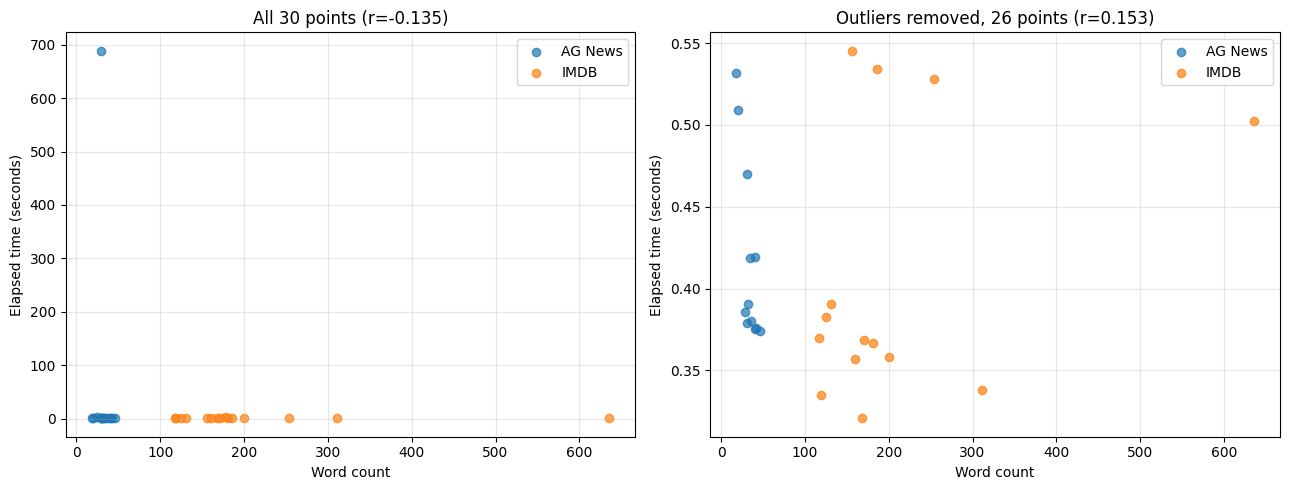

In [ ]:
"""
Outlier-Robust Reanalysis of annotation_time_results.csv
=============================================================
The first pass at analyzing pilot timing data can be dominated by a single
outlier (e.g. a moment where the annotator was interrupted or distracted --
common and expected in a small, informal self-timed pilot). This script
re-analyzes the SAME saved CSV, but detects and reports outliers explicitly
using the IQR method, then computes correlation both with and without them,
so the result isn't silently distorted by one atypical data point.

Run this in the SAME Colab session/folder as annotation_time_pilot.py,
AFTER that script has already produced annotation_time_results.csv --
this does not require redoing the timed labeling.

    python reanalyze_annotation_time.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_COST = 1.0
LENGTH_FACTOR = 0.02


def detect_outliers_iqr(values):
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    return values > upper_bound


def main():
    df = pd.read_csv("annotation_time_results.csv")
    print(f"Loaded {len(df)} timed examples from annotation_time_results.csv\n")

    is_outlier = detect_outliers_iqr(df["elapsed_seconds"].values)
    n_outliers = is_outlier.sum()
    print(f"Detected {n_outliers} outlier(s) via IQR method:")
    if n_outliers > 0:
        print(df.loc[is_outlier, ["domain", "example_index", "word_count", "elapsed_seconds"]]
              .to_string(index=False))
        print("\n(These are likely moments of distraction/interruption during the pilot,")
        print(" not genuine reading time -- common and expected in a small self-timed study.)\n")

    clean_df = df.loc[~is_outlier]

    # Correlation WITH all points (including outliers)
    corr_all = np.corrcoef(df["word_count"], df["elapsed_seconds"])[0, 1]
    print(f"Correlation (word count vs. elapsed time), ALL {len(df)} points: {corr_all:.3f}")

    # Correlation WITHOUT outliers -- the more trustworthy number
    if len(clean_df) >= 3:
        corr_clean = np.corrcoef(clean_df["word_count"], clean_df["elapsed_seconds"])[0, 1]
        print(f"Correlation (word count vs. elapsed time), outliers removed "
              f"({len(clean_df)} points): {corr_clean:.3f}")
    else:
        corr_clean = None
        print("Not enough non-outlier points left for a reliable correlation.")

    print(f"\n{'='*60}")
    if corr_clean is not None:
        if corr_clean > 0.3:
            print(f"With the outlier(s) excluded, timing DOES correlate positively")
            print(f"with length (r={corr_clean:.3f}) -- this supports the paper's")
            print(f"length-based cost model as a reasonable approximation.")
        elif corr_clean < -0.1:
            print(f"Even with outliers excluded, timing does not correlate positively")
            print(f"with length (r={corr_clean:.3f}) in this small pilot. Worth noting")
            print(f"honestly as a limitation -- 30 examples from one annotator is a")
            print(f"small sample, and other factors (label ambiguity, topic familiarity,")
            print(f"reading speed variation) may matter more than raw length.")
        else:
            print(f"Weak/inconclusive correlation (r={corr_clean:.3f}) even with outliers")
            print(f"removed -- a larger, multi-annotator pilot would be needed for a")
            print(f"confident conclusion either way.")
    print(f"{'='*60}")

    # Plot: both views side by side
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors = {"AG News": "tab:blue", "IMDB": "tab:orange"}

    for domain in df["domain"].unique():
        sub = df[df["domain"] == domain]
        axes[0].scatter(sub["word_count"], sub["elapsed_seconds"],
                         label=domain, color=colors.get(domain), alpha=0.7)
    axes[0].set_title(f"All {len(df)} points (r={corr_all:.3f})")
    axes[0].set_xlabel("Word count")
    axes[0].set_ylabel("Elapsed time (seconds)")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    for domain in clean_df["domain"].unique():
        sub = clean_df[clean_df["domain"] == domain]
        axes[1].scatter(sub["word_count"], sub["elapsed_seconds"],
                         label=domain, color=colors.get(domain), alpha=0.7)
    title_r = f"{corr_clean:.3f}" if corr_clean is not None else "N/A"
    axes[1].set_title(f"Outliers removed, {len(clean_df)} points (r={title_r})")
    axes[1].set_xlabel("Word count")
    axes[1].set_ylabel("Elapsed time (seconds)")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("annotation_time_validation_clean.png", dpi=150)
    print("\nSaved comparison plot to annotation_time_validation_clean.png")


if __name__ == "__main__":
    main()

Loaded real fancyzhx/ag_news: 6000 train / 2000 test (classes present in train: [0, 1, 2, 3])
Loading embedding model sentence-transformers/all-MiniLM-L6-v2 (downloads on first use)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Encoding training texts...


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Encoding test texts...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embeddings shape: train (6000, 384), test (2000, 384)

=== Seed 1/5 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

=== Seed 2/5 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

=== Seed 3/5 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

=== Seed 4/5 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

=== Seed 5/5 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

Saved raw results to transformer_embeddings_results.csv
Saved plot to transformer_embeddings_curve.png

Cost needed to reach 

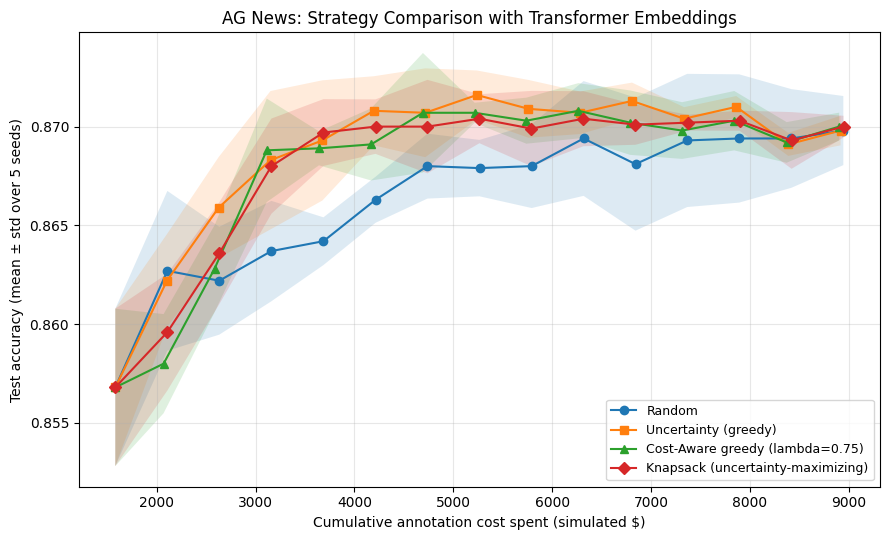

In [ ]:
"""
Transformer Embeddings vs. TF-IDF: Does the Cost-Variance Finding Hold?
============================================================================
All prior experiments used TF-IDF + logistic regression. This script repeats
the core comparison (Random, Uncertainty, Cost-Aware, Knapsack) using FROZEN
pretrained transformer embeddings instead of TF-IDF, keeping logistic
regression as the classifier head.

Why frozen embeddings, not full fine-tuning: fully fine-tuning a transformer
at every one of 15 rounds x 5 seeds would be far too slow/expensive to run on
free-tier Colab. Using a frozen sentence-transformer as a feature extractor is
a standard, defensible compromise: it tests whether the results depend on the
TF-IDF representation specifically, without the cost of full fine-tuning. Full
fine-tuning is noted as future work in the paper.

Model: sentence-transformers/all-MiniLM-L6-v2 (small, fast, strong general-purpose
sentence embedding model, 384 dimensions).

Run:
    python al_transformer_embeddings.py

Output:
    - transformer_embeddings_curve.png
    - transformer_embeddings_results.csv
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

RANDOM_SEED = 42

BASE_COST = 1.0
LENGTH_FACTOR = 0.02
BEST_LAMBDA = 0.75
N_SEEDS = 5
N_ROUNDS = 15
MAX_TRAIN = 6000
MAX_TEST = 2000
N_CANDIDATES_MULTIPLIER = 5
COST_PRECISION = 10

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"


def load_dataset_safe(hf_name, text_field="text", label_field="label",
                       max_train=MAX_TRAIN, max_test=MAX_TEST, max_words=200):
    try:
        from datasets import load_dataset
        ds = load_dataset(hf_name)
        train_split = ds["train"].shuffle(seed=RANDOM_SEED)
        test_split = ds["test"].shuffle(seed=RANDOM_SEED)

        def clip(texts):
            return [" ".join(t.split()[:max_words]) for t in texts]

        train_texts = clip(train_split[text_field][:max_train])
        train_labels = train_split[label_field][:max_train]
        test_texts = clip(test_split[text_field][:max_test])
        test_labels = test_split[label_field][:max_test]
        print(f"Loaded real {hf_name}: {len(train_texts)} train / {len(test_texts)} test "
              f"(classes present in train: {sorted(set(train_labels))})")
        return train_texts, train_labels, test_texts, test_labels
    except Exception as e:
        print(f"[!] Could not download {hf_name} ({e}).")
        print("[!] Falling back to SYNTHETIC data so you can test the pipeline offline.")
        print("[!] Run this script on your own machine / Colab with internet for real results.\n")
        return generate_synthetic_dataset(max_train, max_test)


def generate_synthetic_dataset(n_train, n_test):
    topics = {
        0: ["stock market rises", "company earnings report", "economy grows this quarter", "bank interest rates"],
        1: ["team wins championship", "player scores goal", "olympic athlete trains", "football match tonight"],
        2: ["new smartphone released", "software update improves", "tech company launches product", "computer chip design"],
        3: ["election results announced", "government passes law", "president gives speech", "international summit held"],
    }
    def sample(n):
        texts, labels = [], []
        for _ in range(n):
            label = np.random.randint(0, 4)
            base = np.random.choice(topics[label])
            noise = " ".join(np.random.choice(
                ["today", "yesterday", "reports say", "officials confirm", "sources indicate"],
                size=np.random.randint(1, 8)))
            texts.append(f"{base} {noise}")
            labels.append(label)
        return texts, labels
    train_texts, train_labels = sample(n_train)
    test_texts, test_labels = sample(n_test)
    return train_texts, train_labels, test_texts, test_labels


def compute_costs(texts):
    return np.array([BASE_COST + LENGTH_FACTOR * len(t.split()) for t in texts])


def embed_texts(train_texts, test_texts):
    """
    Encodes texts with a frozen pretrained sentence-transformer.
    Falls back to TF-IDF (with a clear warning) if the model can't be
    downloaded -- e.g. no internet access in a sandboxed environment.
    """
    try:
        from sentence_transformers import SentenceTransformer
        print(f"Loading embedding model {EMBEDDING_MODEL_NAME} (downloads on first use)...")
        model = SentenceTransformer(EMBEDDING_MODEL_NAME)
        print("Encoding training texts...")
        X_train = model.encode(train_texts, show_progress_bar=True, batch_size=64)
        print("Encoding test texts...")
        X_test = model.encode(test_texts, show_progress_bar=True, batch_size=64)
        print(f"Embeddings shape: train {X_train.shape}, test {X_test.shape}")
        return np.asarray(X_train), np.asarray(X_test), True
    except Exception as e:
        print(f"[!] Could not load/download embedding model ({e}).")
        print("[!] Falling back to TF-IDF so the pipeline can still be smoke-tested.")
        print("[!] Run this on a machine with internet access for real transformer results.\n")
        from sklearn.feature_extraction.text import TfidfVectorizer
        vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
        X_train = vectorizer.fit_transform(train_texts).toarray()
        X_test = vectorizer.transform(test_texts).toarray()
        return X_train, X_test, False


def solve_knapsack(values, costs, budget_units):
    n = len(values)
    dp = np.zeros(budget_units + 1)
    choice = np.zeros((n, budget_units + 1), dtype=bool)
    for i in range(n):
        c_i = costs[i]
        v_i = values[i]
        if c_i > budget_units:
            continue
        for c in range(budget_units, c_i - 1, -1):
            candidate = dp[c - c_i] + v_i
            if candidate > dp[c]:
                dp[c] = candidate
                choice[i, c] = True
    selected = []
    c = budget_units
    for i in range(n - 1, -1, -1):
        if choice[i, c]:
            selected.append(i)
            c -= costs[i]
    return selected


def run_strategy(X_train, y_train, X_test, y_test, costs, batch_size, n_rounds,
                  seed_size, strategy="random", cost_lambda=None):
    n_total = X_train.shape[0]
    all_idx = np.arange(n_total)
    np.random.shuffle(all_idx)

    labeled_idx = list(all_idx[:seed_size])
    unlabeled_idx = list(all_idx[seed_size:])

    accuracies, cum_cost = [], []
    total_cost = costs[labeled_idx].sum()
    mean_cost = costs.mean()

    for r in range(n_rounds):
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train[labeled_idx], np.array(y_train)[labeled_idx])

        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        accuracies.append(acc)
        cum_cost.append(total_cost)

        if not unlabeled_idx:
            break

        if strategy == "random":
            n_pick = min(batch_size, len(unlabeled_idx))
            pick_idx = list(np.random.choice(unlabeled_idx, size=n_pick, replace=False))

        elif strategy == "knapsack":
            probs = clf.predict_proba(X_train[unlabeled_idx])
            uncertainty = 1 - probs.max(axis=1)
            n_candidates = min(len(unlabeled_idx), batch_size * N_CANDIDATES_MULTIPLIER)
            top_order = np.argsort(-uncertainty)[:n_candidates]
            candidate_global_idx = [unlabeled_idx[i] for i in top_order]
            candidate_values = uncertainty[top_order]
            candidate_costs_raw = costs[candidate_global_idx]
            candidate_costs_int = np.round(candidate_costs_raw * COST_PRECISION).astype(int)
            candidate_costs_int = np.maximum(candidate_costs_int, 1)
            budget_units = int(round(batch_size * mean_cost * COST_PRECISION))
            selected_local = solve_knapsack(candidate_values, candidate_costs_int, budget_units)
            pick_idx = [candidate_global_idx[i] for i in selected_local]
            if not pick_idx:
                n_pick = min(batch_size, len(unlabeled_idx))
                pick_idx = [unlabeled_idx[i] for i in top_order[:n_pick]]

        else:  # "uncertainty" (greedy, optionally cost-weighted)
            probs = clf.predict_proba(X_train[unlabeled_idx])
            uncertainty = 1 - probs.max(axis=1)
            if cost_lambda:
                sample_costs = costs[unlabeled_idx]
                score = uncertainty / np.power(sample_costs, cost_lambda)
            else:
                score = uncertainty
            n_pick = min(batch_size, len(unlabeled_idx))
            order = np.argsort(-score)[:n_pick]
            pick_idx = [unlabeled_idx[i] for i in order]

        labeled_idx.extend(pick_idx)
        total_cost += costs[pick_idx].sum()
        pick_set = set(pick_idx)
        unlabeled_idx = [i for i in unlabeled_idx if i not in pick_set]

    return cum_cost, accuracies


def main():
    train_texts, train_labels, test_texts, test_labels = load_dataset_safe("fancyzhx/ag_news")
    X_train, X_test, used_real_embeddings = embed_texts(train_texts, test_texts)
    costs = compute_costs(train_texts)

    batch_size = max(50, X_train.shape[0] // 20)
    seed_size = batch_size * 3

    strategies = {
        "Random": ("random", None),
        "Uncertainty (greedy)": ("uncertainty", None),
        f"Cost-Aware greedy (lambda={BEST_LAMBDA})": ("uncertainty", BEST_LAMBDA),
        "Knapsack (uncertainty-maximizing)": ("knapsack", None),
    }

    raw_runs = {s: [] for s in strategies}
    for seed in range(N_SEEDS):
        print(f"\n=== Seed {seed + 1}/{N_SEEDS} ===")
        for sname, (strat, lam) in strategies.items():
            np.random.seed(RANDOM_SEED + seed)
            print(f"  Running {sname}...")
            cum_cost, acc = run_strategy(
                X_train, train_labels, X_test, test_labels, costs,
                batch_size, N_ROUNDS, seed_size, strategy=strat, cost_lambda=lam)
            raw_runs[sname].append((np.array(cum_cost), np.array(acc)))

    aggregated = {}
    for sname, runs in raw_runs.items():
        min_len = min(len(a) for _, a in runs)
        accs = np.array([a[:min_len] for _, a in runs])
        costs_arr = np.array([c[:min_len] for c, _ in runs])
        aggregated[sname] = {
            "cost_mean": costs_arr.mean(axis=0),
            "acc_mean": accs.mean(axis=0),
            "acc_std": accs.std(axis=0),
        }

    df_dict = {}
    for sname, v in aggregated.items():
        key = "".join(c if c.isalnum() else "_" for c in sname)
        df_dict[f"cost_{key}"] = pd.Series(v["cost_mean"])
        df_dict[f"acc_mean_{key}"] = pd.Series(v["acc_mean"])
        df_dict[f"acc_std_{key}"] = pd.Series(v["acc_std"])
    pd.DataFrame(df_dict).to_csv("transformer_embeddings_results.csv", index=False)
    print("\nSaved raw results to transformer_embeddings_results.csv")

    plt.figure(figsize=(9, 5.5))
    markers = ["o", "s", "^", "D"]
    for (sname, v), m in zip(aggregated.items(), markers):
        plt.plot(v["cost_mean"], v["acc_mean"], marker=m, label=sname)
        plt.fill_between(v["cost_mean"], v["acc_mean"] - v["acc_std"],
                          v["acc_mean"] + v["acc_std"], alpha=0.15)
    plt.xlabel("Cumulative annotation cost spent (simulated $)")
    plt.ylabel(f"Test accuracy (mean \u00b1 std over {N_SEEDS} seeds)")
    embedding_label = "Transformer Embeddings" if used_real_embeddings else "TF-IDF FALLBACK (no internet)"
    plt.title(f"AG News: Strategy Comparison with {embedding_label}")
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("transformer_embeddings_curve.png", dpi=150)
    print("Saved plot to transformer_embeddings_curve.png")

    peak = max(v["acc_mean"].max() for v in aggregated.values())
    target = 0.98 * peak
    print(f"\nCost needed to reach {target:.2%} accuracy (98% of peak {peak:.2%}), averaged over {N_SEEDS} seeds:")
    cost_needed = {}
    for sname, v in aggregated.items():
        needed = next((c for c, a in zip(v["cost_mean"], v["acc_mean"]) if a >= target), None)
        cost_needed[sname] = needed
        print(f"  {sname:<38}: {needed}")

    baseline = cost_needed.get("Random")
    print()
    for sname, needed in cost_needed.items():
        if sname == "Random" or needed is None or baseline is None:
            continue
        savings = (1 - needed / baseline) * 100
        print(f"--> {sname} saves {savings:.1f}% of budget vs random")

    # IMPORTANT: with strong embeddings, accuracy can saturate almost
    # immediately (even the initial seed set reaches near-peak accuracy),
    # which makes "cost needed to reach X% of peak" trivially identical
    # across strategies -- not a real null result, just a blunt metric.
    # Report accuracy at MATCHED cost checkpoints instead, which stays
    # informative even when the threshold-crossing metric saturates.
    print(f"\n{'='*70}")
    print("Accuracy at matched cost checkpoints (more informative when the")
    print("threshold metric above saturates immediately, as it may with strong")
    print("embeddings that already perform well from a small seed set):")
    print(f"{'='*70}")
    random_costs = aggregated["Random"]["cost_mean"]
    n_checkpoints = min(8, len(random_costs))
    checkpoint_indices = np.linspace(0, len(random_costs) - 1, n_checkpoints).astype(int)
    header = f"{'Cost':>8} | " + " | ".join(f"{n[:22]:>22}" for n in aggregated.keys())
    print(header)
    for idx in checkpoint_indices:
        row = f"{random_costs[idx]:>8.0f} | "
        row += " | ".join(f"{aggregated[n]['acc_mean'][idx]:>22.2%}" for n in aggregated.keys())
        print(row)

    print(f"\nCheck: do Uncertainty/Cost-Aware/Knapsack columns show consistently")
    print(f"higher accuracy than Random at the SAME cost checkpoint? If so, active")
    print(f"learning still helps here -- the earlier 0% number was a metric")
    print(f"artifact, not evidence that AL stopped working with real embeddings.")

    print(f"\n{'='*60}")
    if used_real_embeddings:
        print("These results use REAL frozen transformer embeddings.")
        print("Compare the savings percentages above to the TF-IDF results")
        print("from al_knapsack.py on the same AG News data -- if the pattern")
        print("(knapsack >= greedy cost-aware >= random) holds here too, that's")
        print("evidence the findings aren't an artifact of the TF-IDF representation.")
    else:
        print("[!] These results used the TF-IDF FALLBACK, not real transformer")
        print("[!] embeddings, because the embedding model could not be downloaded.")
        print("[!] Re-run this script with internet access for the real comparison.")
    print(f"{'='*60}")


if __name__ == "__main__":
    main()

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Loaded real fancyzhx/ag_news: 6000 train / 2000 test

COST DISTRIBUTION: CV = 0.0
  Seed 1/10 done
  Seed 2/10 done
  Seed 3/10 done
  Seed 4/10 done
  Seed 5/10 done
  Seed 6/10 done
  Seed 7/10 done
  Seed 8/10 done
  Seed 9/10 done
  Seed 10/10 done
Cost needed to reach 86.82% accuracy (98% of peak 88.59%), aggregate curve:
  Random                                : 5874.0
  Uncertainty (greedy)                  : 3738.000000000001
  Cost-Aware greedy (lambda=0.75)       : 3738.000000000001
  Knapsack                              : 3709.5200000000013

  Per-seed paired results (n=10 seeds), mean [95% bootstrap CI]:
    Uncertainty vs Random:        +28.7% [+21.1%, +36.1%]
    Knapsack vs Uncertainty:      +0.4% [-5.3%, +6.1%]
    Cost-Aware vs Uncertainty:    +0.0% [+0.0%, +0.0%]
  --> Knapsack vs plain Uncertainty at CV=0.0: +0.4% [95% CI: -5.3%, +6.1%]

COST DISTRIBUTION: CV = 0.1
  Seed 1/10 done
  Seed 2/10 done
  Seed 3/10 done
  Seed 4/10 done
  Seed 5/10 done
  Seed 6/10 done


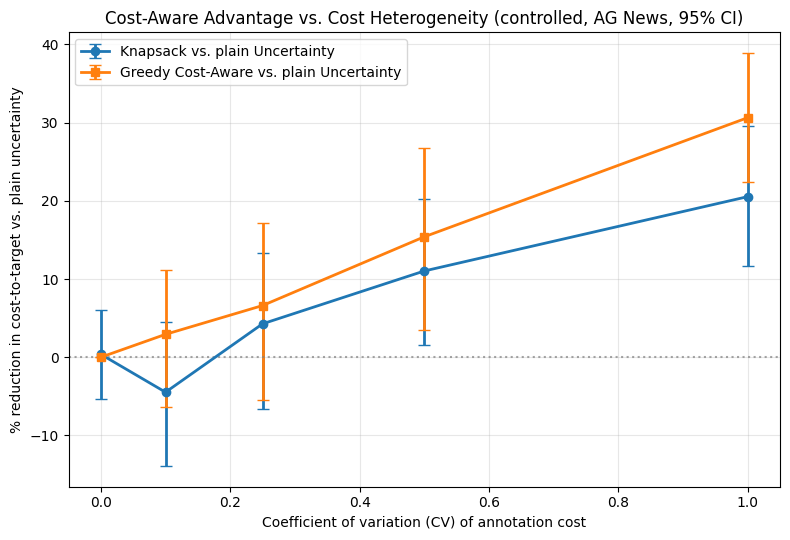

In [ ]:
"""
Controlled Cost-Variance Experiment
=======================================
The AG News vs IMDB comparison (Sections 4.4-4.5) shows knapsack's advantage
is larger on the high-cost-variance dataset. But with only two datasets, that
is a correlation across two observations, not a controlled test -- a critic
could reasonably say the difference is due to domain, task difficulty, or
something else about IMDB, not cost variance specifically.

This script controls for that: it uses ONE dataset (AG News) with the SAME
labels throughout, and manipulates ONLY the cost distribution's variance
(via its coefficient of variation, CV = std/mean), holding everything else
fixed. If knapsack's advantage over plain uncertainty grows smoothly as CV
increases, that is much stronger evidence for the cost-variance mechanism
than the two-dataset comparison alone.

Cost distributions tested (same mean cost, increasing variance):
    CV = 0.0   (all samples cost the same -- degenerate control)
    CV = 0.1   (low variance)
    CV = 0.25  (medium-low)
    CV = 0.5   (medium-high)
    CV = 1.0   (high variance)

Costs are assigned via a lognormal distribution parameterized to hit each
target CV, independent of text length/content -- so any effect we see is
attributable to cost variance itself, not a length/informativeness
confound. (A second run using length-derived costs at matched CVs is a
natural follow-up, noted in the paper's future work.)

Uses N_SEEDS = 10 (increased from 5 in earlier experiments) since this
experiment's claims rest on comparing differences across CV levels, which
needs tighter confidence intervals.

Run:
    python al_cost_variance_controlled.py

Output:
    - cost_variance_controlled_curve.png  (knapsack advantage vs CV)
    - cost_variance_controlled_results.csv
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

RANDOM_SEED = 42
N_SEEDS = 10
N_ROUNDS = 15
MAX_TRAIN = 6000
MAX_TEST = 2000
BEST_LAMBDA = 0.75
N_CANDIDATES_MULTIPLIER = 5
COST_PRECISION = 10

MEAN_COST = 1.78  # matches the mean cost used in earlier AG News experiments
CV_LEVELS = [0.0, 0.1, 0.25, 0.5, 1.0]


def load_dataset_safe(hf_name, text_field="text", label_field="label",
                       max_train=MAX_TRAIN, max_test=MAX_TEST, max_words=200):
    try:
        from datasets import load_dataset
        ds = load_dataset(hf_name)
        train_split = ds["train"].shuffle(seed=RANDOM_SEED)
        test_split = ds["test"].shuffle(seed=RANDOM_SEED)

        def clip(texts):
            return [" ".join(t.split()[:max_words]) for t in texts]

        train_texts = clip(train_split[text_field][:max_train])
        train_labels = train_split[label_field][:max_train]
        test_texts = clip(test_split[text_field][:max_test])
        test_labels = test_split[label_field][:max_test]
        print(f"Loaded real {hf_name}: {len(train_texts)} train / {len(test_texts)} test")
        return train_texts, train_labels, test_texts, test_labels
    except Exception as e:
        print(f"[!] Could not download {hf_name} ({e}).")
        print("[!] Falling back to SYNTHETIC data so you can test the pipeline offline.")
        print("[!] Run this script on your own machine / Colab with internet for real results.\n")
        return generate_synthetic_dataset(max_train, max_test)


def generate_synthetic_dataset(n_train, n_test):
    topics = {
        0: ["stock market rises", "company earnings report", "economy grows this quarter", "bank interest rates"],
        1: ["team wins championship", "player scores goal", "olympic athlete trains", "football match tonight"],
        2: ["new smartphone released", "software update improves", "tech company launches product", "computer chip design"],
        3: ["election results announced", "government passes law", "president gives speech", "international summit held"],
    }
    def sample(n):
        texts, labels = [], []
        for _ in range(n):
            label = np.random.randint(0, 4)
            base = np.random.choice(topics[label])
            noise = " ".join(np.random.choice(
                ["today", "yesterday", "reports say", "officials confirm", "sources indicate"],
                size=np.random.randint(1, 8)))
            texts.append(f"{base} {noise}")
            labels.append(label)
        return texts, labels
    train_texts, train_labels = sample(n_train)
    test_texts, test_labels = sample(n_test)
    return train_texts, train_labels, test_texts, test_labels


def generate_controlled_costs(n_samples, mean_cost, cv, seed):
    """
    Generates costs independent of text content, with EXACTLY the target
    mean and coefficient of variation, via a lognormal distribution.
    CV = 0.0 is a degenerate case: every sample costs exactly mean_cost.
    """
    rng = np.random.default_rng(seed)
    if cv <= 1e-9:
        return np.full(n_samples, mean_cost)
    sigma2 = np.log(1 + cv ** 2)
    sigma = np.sqrt(sigma2)
    mu = np.log(mean_cost) - sigma2 / 2
    costs = rng.lognormal(mean=mu, sigma=sigma, size=n_samples)
    return costs


def vectorize(train_texts, test_texts):
    vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    return X_train, X_test


def solve_knapsack(values, costs, budget_units):
    n = len(values)
    dp = np.zeros(budget_units + 1)
    choice = np.zeros((n, budget_units + 1), dtype=bool)
    for i in range(n):
        c_i = costs[i]
        v_i = values[i]
        if c_i > budget_units:
            continue
        for c in range(budget_units, c_i - 1, -1):
            candidate = dp[c - c_i] + v_i
            if candidate > dp[c]:
                dp[c] = candidate
                choice[i, c] = True
    selected = []
    c = budget_units
    for i in range(n - 1, -1, -1):
        if choice[i, c]:
            selected.append(i)
            c -= costs[i]
    return selected


def run_strategy(X_train, y_train, X_test, y_test, costs, batch_size, n_rounds,
                  seed_size, strategy="random", cost_lambda=None):
    n_total = X_train.shape[0]
    all_idx = np.arange(n_total)
    np.random.shuffle(all_idx)

    labeled_idx = list(all_idx[:seed_size])
    unlabeled_idx = list(all_idx[seed_size:])

    accuracies, cum_cost = [], []
    total_cost = costs[labeled_idx].sum()
    mean_cost = costs.mean()

    for r in range(n_rounds):
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train[labeled_idx], np.array(y_train)[labeled_idx])

        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        accuracies.append(acc)
        cum_cost.append(total_cost)

        if not unlabeled_idx:
            break

        if strategy == "random":
            n_pick = min(batch_size, len(unlabeled_idx))
            pick_idx = list(np.random.choice(unlabeled_idx, size=n_pick, replace=False))

        elif strategy == "knapsack":
            probs = clf.predict_proba(X_train[unlabeled_idx])
            uncertainty = 1 - probs.max(axis=1)
            n_candidates = min(len(unlabeled_idx), batch_size * N_CANDIDATES_MULTIPLIER)
            top_order = np.argsort(-uncertainty)[:n_candidates]
            candidate_global_idx = [unlabeled_idx[i] for i in top_order]
            candidate_values = uncertainty[top_order]
            candidate_costs_raw = costs[candidate_global_idx]
            candidate_costs_int = np.round(candidate_costs_raw * COST_PRECISION).astype(int)
            candidate_costs_int = np.maximum(candidate_costs_int, 1)
            budget_units = int(round(batch_size * mean_cost * COST_PRECISION))
            selected_local = solve_knapsack(candidate_values, candidate_costs_int, budget_units)
            pick_idx = [candidate_global_idx[i] for i in selected_local]
            if not pick_idx:
                n_pick = min(batch_size, len(unlabeled_idx))
                pick_idx = [unlabeled_idx[i] for i in top_order[:n_pick]]

        else:  # "uncertainty" (greedy, optionally cost-weighted)
            probs = clf.predict_proba(X_train[unlabeled_idx])
            uncertainty = 1 - probs.max(axis=1)
            if cost_lambda:
                sample_costs = costs[unlabeled_idx]
                score = uncertainty / np.power(sample_costs, cost_lambda)
            else:
                score = uncertainty
            n_pick = min(batch_size, len(unlabeled_idx))
            order = np.argsort(-score)[:n_pick]
            pick_idx = [unlabeled_idx[i] for i in order]

        labeled_idx.extend(pick_idx)
        total_cost += costs[pick_idx].sum()
        pick_set = set(pick_idx)
        unlabeled_idx = [i for i in unlabeled_idx if i not in pick_set]

    return cum_cost, accuracies


def cost_to_target(cost_mean, acc_mean, target):
    return next((c for c, a in zip(cost_mean, acc_mean) if a >= target), None)


def bootstrap_ci(values, n_bootstrap=10000, ci=95, seed=0):
    """
    Bootstrap confidence interval for the mean of a small sample of per-seed
    values. Resamples with replacement many times and takes percentiles --
    doesn't assume normality, appropriate for N=10 seeds.
    Returns (mean, ci_low, ci_high).
    """
    values = np.array([v for v in values if v is not None])
    if len(values) < 2:
        return (values[0] if len(values) else None, None, None)
    rng = np.random.default_rng(seed)
    boot_means = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    lo_pct, hi_pct = (100 - ci) / 2, 100 - (100 - ci) / 2
    return values.mean(), np.percentile(boot_means, lo_pct), np.percentile(boot_means, hi_pct)


def main():
    train_texts, train_labels, test_texts, test_labels = load_dataset_safe("fancyzhx/ag_news")
    X_train, X_test = vectorize(train_texts, test_texts)
    n_samples = X_train.shape[0]

    batch_size = max(50, n_samples // 20)
    seed_size = batch_size * 3

    strategies = {
        "Random": ("random", None),
        "Uncertainty (greedy)": ("uncertainty", None),
        f"Cost-Aware greedy (lambda={BEST_LAMBDA})": ("uncertainty", BEST_LAMBDA),
        "Knapsack": ("knapsack", None),
    }

    summary_rows = []

    for cv in CV_LEVELS:
        print(f"\n{'='*70}")
        print(f"COST DISTRIBUTION: CV = {cv}")
        print(f"{'='*70}")

        raw_runs = {s: [] for s in strategies}
        for seed in range(N_SEEDS):
            # Same cost realization across strategies within a seed, so all
            # strategies face the identical cost landscape for that seed --
            # only the SELECTION differs.
            costs = generate_controlled_costs(n_samples, MEAN_COST, cv, seed=RANDOM_SEED + seed)
            for sname, (strat, lam) in strategies.items():
                np.random.seed(RANDOM_SEED + seed)
                cum_cost, acc = run_strategy(
                    X_train, train_labels, X_test, test_labels, costs,
                    batch_size, N_ROUNDS, seed_size, strategy=strat, cost_lambda=lam)
                raw_runs[sname].append((np.array(cum_cost), np.array(acc)))
            print(f"  Seed {seed + 1}/{N_SEEDS} done")

        aggregated = {}
        for sname, runs in raw_runs.items():
            min_len = min(len(a) for _, a in runs)
            accs = np.array([a[:min_len] for _, a in runs])
            costs_arr = np.array([c[:min_len] for c, _ in runs])
            aggregated[sname] = {
                "cost_mean": costs_arr.mean(axis=0),
                "acc_mean": accs.mean(axis=0),
                "acc_std": accs.std(axis=0),
            }

        peak = max(v["acc_mean"].max() for v in aggregated.values())
        target = 0.98 * peak
        cost_needed = {sname: cost_to_target(v["cost_mean"], v["acc_mean"], target)
                       for sname, v in aggregated.items()}

        print(f"Cost needed to reach {target:.2%} accuracy (98% of peak {peak:.2%}), aggregate curve:")
        for sname, needed in cost_needed.items():
            print(f"  {sname:<38}: {needed}")

        # --- Per-seed, PAIRED computation for confidence intervals ---
        # Using the aggregate curve above gives one number with no sense of
        # spread. Instead, compute cost-to-target SEPARATELY for each seed's
        # own curve (paired: same seed's cost realization for every
        # strategy), then bootstrap a CI over those per-seed % differences.
        # This directly addresses "is 29.3% statistically stable?"
        per_seed_knapsack_vs_uncertainty = []
        per_seed_costaware_vs_uncertainty = []
        per_seed_uncertainty_vs_random = []
        for seed_i in range(N_SEEDS):
            seed_cost_needed = {}
            for sname, runs in raw_runs.items():
                cum_cost, acc = runs[seed_i]
                seed_cost_needed[sname] = cost_to_target(cum_cost, acc, target)
            r = seed_cost_needed.get("Random")
            u = seed_cost_needed.get("Uncertainty (greedy)")
            k = seed_cost_needed.get("Knapsack")
            ca = seed_cost_needed.get(f"Cost-Aware greedy (lambda={BEST_LAMBDA})")
            if u and k:
                per_seed_knapsack_vs_uncertainty.append((1 - k / u) * 100)
            if u and ca:
                per_seed_costaware_vs_uncertainty.append((1 - ca / u) * 100)
            if r and u:
                per_seed_uncertainty_vs_random.append((1 - u / r) * 100)

        knap_mean, knap_lo, knap_hi = bootstrap_ci(per_seed_knapsack_vs_uncertainty, seed=RANDOM_SEED)
        ca_mean, ca_lo, ca_hi = bootstrap_ci(per_seed_costaware_vs_uncertainty, seed=RANDOM_SEED)
        unc_mean, unc_lo, unc_hi = bootstrap_ci(per_seed_uncertainty_vs_random, seed=RANDOM_SEED)

        print(f"\n  Per-seed paired results (n={N_SEEDS} seeds), mean [95% bootstrap CI]:")
        if unc_mean is not None:
            print(f"    Uncertainty vs Random:        {unc_mean:+.1f}% [{unc_lo:+.1f}%, {unc_hi:+.1f}%]")
        if knap_mean is not None:
            print(f"    Knapsack vs Uncertainty:      {knap_mean:+.1f}% [{knap_lo:+.1f}%, {knap_hi:+.1f}%]")
        if ca_mean is not None:
            print(f"    Cost-Aware vs Uncertainty:    {ca_mean:+.1f}% [{ca_lo:+.1f}%, {ca_hi:+.1f}%]")

        random_cost = cost_needed.get("Random")
        uncertainty_cost = cost_needed.get("Uncertainty (greedy)")
        knapsack_cost = cost_needed.get("Knapsack")
        cost_aware_cost = cost_needed.get(f"Cost-Aware greedy (lambda={BEST_LAMBDA})")

        row = {"cv": cv}
        if random_cost:
            for sname, needed in cost_needed.items():
                if needed is not None:
                    row[f"savings_vs_random_{sname}"] = (1 - needed / random_cost) * 100
        row["knapsack_vs_uncertainty_pct"] = knap_mean
        row["knapsack_vs_uncertainty_ci_lo"] = knap_lo
        row["knapsack_vs_uncertainty_ci_hi"] = knap_hi
        row["costaware_vs_uncertainty_pct"] = ca_mean
        row["costaware_vs_uncertainty_ci_lo"] = ca_lo
        row["costaware_vs_uncertainty_ci_hi"] = ca_hi
        if knap_mean is not None:
            print(f"  --> Knapsack vs plain Uncertainty at CV={cv}: {knap_mean:+.1f}% "
                  f"[95% CI: {knap_lo:+.1f}%, {knap_hi:+.1f}%]")

        summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv("cost_variance_controlled_results.csv", index=False)
    print(f"\n{'='*70}")
    print("SUMMARY: Knapsack/Cost-Aware advantage over plain Uncertainty, by cost CV")
    print("(mean % reduction in cost-to-target, with 95% bootstrap CI)")
    print(f"{'='*70}")
    for _, r in summary_df.iterrows():
        print(f"CV={r['cv']:.2f}  Knapsack: {r['knapsack_vs_uncertainty_pct']:+.1f}% "
              f"[{r['knapsack_vs_uncertainty_ci_lo']:+.1f}%, {r['knapsack_vs_uncertainty_ci_hi']:+.1f}%]"
              f"   Cost-Aware: {r['costaware_vs_uncertainty_pct']:+.1f}% "
              f"[{r['costaware_vs_uncertainty_ci_lo']:+.1f}%, {r['costaware_vs_uncertainty_ci_hi']:+.1f}%]")

    # The key plot for the paper: does the advantage grow smoothly with CV?
    # Error bars show the 95% bootstrap CI across seeds -- addresses
    # "is this difference statistically stable?"
    plt.figure(figsize=(8, 5.5))
    knap_err = [summary_df["knapsack_vs_uncertainty_pct"] - summary_df["knapsack_vs_uncertainty_ci_lo"],
                summary_df["knapsack_vs_uncertainty_ci_hi"] - summary_df["knapsack_vs_uncertainty_pct"]]
    ca_err = [summary_df["costaware_vs_uncertainty_pct"] - summary_df["costaware_vs_uncertainty_ci_lo"],
              summary_df["costaware_vs_uncertainty_ci_hi"] - summary_df["costaware_vs_uncertainty_pct"]]
    plt.errorbar(summary_df["cv"], summary_df["knapsack_vs_uncertainty_pct"], yerr=knap_err,
                 marker="o", label="Knapsack vs. plain Uncertainty", linewidth=2, capsize=4)
    plt.errorbar(summary_df["cv"], summary_df["costaware_vs_uncertainty_pct"], yerr=ca_err,
                 marker="s", label="Greedy Cost-Aware vs. plain Uncertainty", linewidth=2, capsize=4)
    plt.axhline(0, color="gray", linestyle=":", alpha=0.7)
    plt.xlabel("Coefficient of variation (CV) of annotation cost")
    plt.ylabel("% reduction in cost-to-target vs. plain uncertainty")
    plt.title("Cost-Aware Advantage vs. Cost Heterogeneity (controlled, AG News, 95% CI)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("cost_variance_controlled_curve.png", dpi=150)
    print("\nSaved plot to cost_variance_controlled_curve.png")

    print(f"\n{'='*70}")
    print("If the Knapsack line rises smoothly/monotonically as CV increases,")
    print("that is strong controlled evidence for the cost-variance mechanism --")
    print("much stronger than the two-dataset (AG News vs IMDB) comparison alone,")
    print("since dataset domain, task difficulty, and text length are now held")
    print("fixed and ONLY cost variance changes.")
    print(f"{'='*70}")


if __name__ == "__main__":
    main()

Loaded real fancyzhx/ag_news: 6000 train / 2000 test

=== Seed 1/10 ===
  Running Random...
  Running Least-Confidence Uncertainty...
  Running Entropy...
  Running Cost-Aware greedy (LC, lambda=0.75)...
  Running Knapsack (LC)...

=== Seed 2/10 ===
  Running Random...
  Running Least-Confidence Uncertainty...
  Running Entropy...
  Running Cost-Aware greedy (LC, lambda=0.75)...
  Running Knapsack (LC)...

=== Seed 3/10 ===
  Running Random...
  Running Least-Confidence Uncertainty...
  Running Entropy...
  Running Cost-Aware greedy (LC, lambda=0.75)...
  Running Knapsack (LC)...

=== Seed 4/10 ===
  Running Random...
  Running Least-Confidence Uncertainty...
  Running Entropy...
  Running Cost-Aware greedy (LC, lambda=0.75)...
  Running Knapsack (LC)...

=== Seed 5/10 ===
  Running Random...
  Running Least-Confidence Uncertainty...
  Running Entropy...
  Running Cost-Aware greedy (LC, lambda=0.75)...
  Running Knapsack (LC)...

=== Seed 6/10 ===
  Running Random...
  Running Least-Co

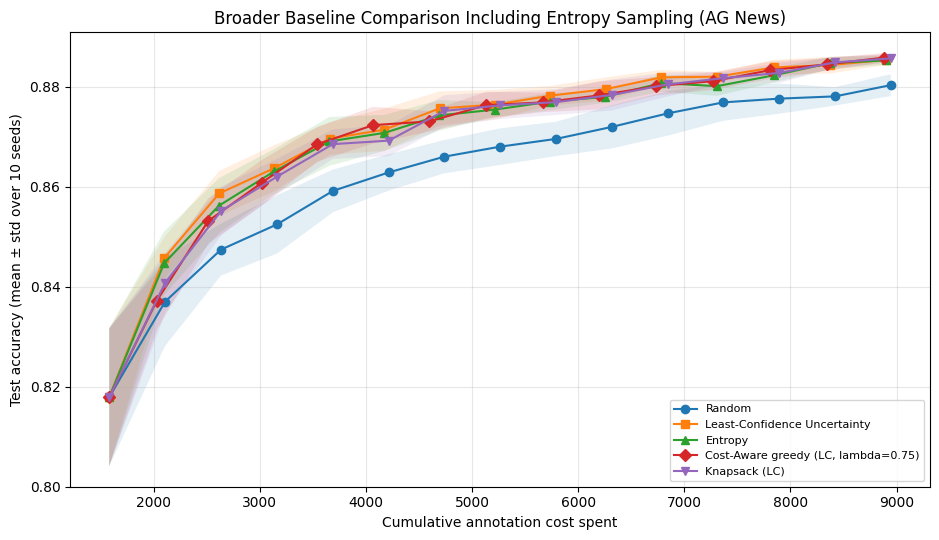

In [ ]:
"""
Broader Baseline Comparison: Adding Entropy Sampling
========================================================
Both independent reviewers flagged the same gap: the paper compares Random,
Least-Confidence Uncertainty, greedy Cost-Aware, and Knapsack, but doesn't
include Entropy sampling -- one of the other standard, widely-used AL
acquisition functions (alongside Least-Confidence and Margin sampling).

This adds Entropy sampling as an additional baseline: entropy(x) =
-sum_c p(c|x) * log(p(c|x)), which (unlike least-confidence) considers the
FULL predicted probability distribution across all classes, not just the
top class. On binary tasks the two are closely related; on multi-class
tasks (like AG News's 4 classes) they can behave differently.

This does NOT add BALD/BatchBALD (which need a Bayesian model and are a
larger undertaking, left as future work per the paper's Limitations
section) -- this specifically closes the "you're missing Entropy" gap,
which is cheap to add since it only changes the scoring formula.

Five strategies compared:
    1. Random
    2. Least-Confidence Uncertainty (the "Uncertainty" baseline used
       throughout the rest of the paper)
    3. Entropy sampling (NEW)
    4. Cost-Aware greedy (lambda=0.75)
    5. Knapsack

Run:
    python al_entropy_baseline.py

Output:
    - entropy_baseline_curve.png
    - entropy_baseline_results.csv
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

RANDOM_SEED = 42

BASE_COST = 1.0
LENGTH_FACTOR = 0.02
BEST_LAMBDA = 0.75
N_SEEDS = 10
N_ROUNDS = 15
MAX_TRAIN = 6000
MAX_TEST = 2000
N_CANDIDATES_MULTIPLIER = 5
COST_PRECISION = 10
EPS = 1e-12  # avoids log(0) in entropy calculation


def load_dataset_safe(hf_name, text_field="text", label_field="label",
                       max_train=MAX_TRAIN, max_test=MAX_TEST, max_words=200):
    try:
        from datasets import load_dataset
        ds = load_dataset(hf_name)
        train_split = ds["train"].shuffle(seed=RANDOM_SEED)
        test_split = ds["test"].shuffle(seed=RANDOM_SEED)

        def clip(texts):
            return [" ".join(t.split()[:max_words]) for t in texts]

        train_texts = clip(train_split[text_field][:max_train])
        train_labels = train_split[label_field][:max_train]
        test_texts = clip(test_split[text_field][:max_test])
        test_labels = test_split[label_field][:max_test]
        print(f"Loaded real {hf_name}: {len(train_texts)} train / {len(test_texts)} test")
        return train_texts, train_labels, test_texts, test_labels
    except Exception as e:
        print(f"[!] Could not download {hf_name} ({e}).")
        print("[!] Falling back to SYNTHETIC data so you can test the pipeline offline.")
        print("[!] Run this script on your own machine / Colab with internet for real results.\n")
        return generate_synthetic_dataset(max_train, max_test)


def generate_synthetic_dataset(n_train, n_test):
    topics = {
        0: ["stock market rises", "company earnings report", "economy grows this quarter", "bank interest rates"],
        1: ["team wins championship", "player scores goal", "olympic athlete trains", "football match tonight"],
        2: ["new smartphone released", "software update improves", "tech company launches product", "computer chip design"],
        3: ["election results announced", "government passes law", "president gives speech", "international summit held"],
    }
    def sample(n):
        texts, labels = [], []
        for _ in range(n):
            label = np.random.randint(0, 4)
            base = np.random.choice(topics[label])
            noise = " ".join(np.random.choice(
                ["today", "yesterday", "reports say", "officials confirm", "sources indicate"],
                size=np.random.randint(1, 8)))
            texts.append(f"{base} {noise}")
            labels.append(label)
        return texts, labels
    train_texts, train_labels = sample(n_train)
    test_texts, test_labels = sample(n_test)
    return train_texts, train_labels, test_texts, test_labels


def compute_costs(texts):
    return np.array([BASE_COST + LENGTH_FACTOR * len(t.split()) for t in texts])


def vectorize(train_texts, test_texts):
    vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    return X_train, X_test


def solve_knapsack(values, costs, budget_units):
    n = len(values)
    dp = np.zeros(budget_units + 1)
    choice = np.zeros((n, budget_units + 1), dtype=bool)
    for i in range(n):
        c_i = costs[i]
        v_i = values[i]
        if c_i > budget_units:
            continue
        for c in range(budget_units, c_i - 1, -1):
            candidate = dp[c - c_i] + v_i
            if candidate > dp[c]:
                dp[c] = candidate
                choice[i, c] = True
    selected = []
    c = budget_units
    for i in range(n - 1, -1, -1):
        if choice[i, c]:
            selected.append(i)
            c -= costs[i]
    return selected


def compute_score(probs, mode):
    """mode: 'least_confidence' | 'entropy'"""
    if mode == "least_confidence":
        return 1 - probs.max(axis=1)
    elif mode == "entropy":
        return -np.sum(probs * np.log(probs + EPS), axis=1)
    else:
        raise ValueError(f"Unknown scoring mode: {mode}")


def run_strategy(X_train, y_train, X_test, y_test, costs, batch_size, n_rounds,
                  seed_size, strategy="random", score_mode="least_confidence", cost_lambda=None):
    n_total = X_train.shape[0]
    all_idx = np.arange(n_total)
    np.random.shuffle(all_idx)

    labeled_idx = list(all_idx[:seed_size])
    unlabeled_idx = list(all_idx[seed_size:])

    accuracies, cum_cost = [], []
    total_cost = costs[labeled_idx].sum()
    mean_cost = costs.mean()

    for r in range(n_rounds):
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train[labeled_idx], np.array(y_train)[labeled_idx])

        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        accuracies.append(acc)
        cum_cost.append(total_cost)

        if not unlabeled_idx:
            break

        if strategy == "random":
            n_pick = min(batch_size, len(unlabeled_idx))
            pick_idx = list(np.random.choice(unlabeled_idx, size=n_pick, replace=False))

        elif strategy == "knapsack":
            probs = clf.predict_proba(X_train[unlabeled_idx])
            score = compute_score(probs, score_mode)
            n_candidates = min(len(unlabeled_idx), batch_size * N_CANDIDATES_MULTIPLIER)
            top_order = np.argsort(-score)[:n_candidates]
            candidate_global_idx = [unlabeled_idx[i] for i in top_order]
            candidate_values = score[top_order]
            candidate_costs_raw = costs[candidate_global_idx]
            candidate_costs_int = np.round(candidate_costs_raw * COST_PRECISION).astype(int)
            candidate_costs_int = np.maximum(candidate_costs_int, 1)
            budget_units = int(round(batch_size * mean_cost * COST_PRECISION))
            selected_local = solve_knapsack(candidate_values, candidate_costs_int, budget_units)
            pick_idx = [candidate_global_idx[i] for i in selected_local]
            if not pick_idx:
                n_pick = min(batch_size, len(unlabeled_idx))
                pick_idx = [unlabeled_idx[i] for i in top_order[:n_pick]]

        else:  # greedy ranking (optionally cost-weighted), using score_mode
            probs = clf.predict_proba(X_train[unlabeled_idx])
            score = compute_score(probs, score_mode)
            if cost_lambda:
                sample_costs = costs[unlabeled_idx]
                score = score / np.power(sample_costs, cost_lambda)
            n_pick = min(batch_size, len(unlabeled_idx))
            order = np.argsort(-score)[:n_pick]
            pick_idx = [unlabeled_idx[i] for i in order]

        labeled_idx.extend(pick_idx)
        total_cost += costs[pick_idx].sum()
        pick_set = set(pick_idx)
        unlabeled_idx = [i for i in unlabeled_idx if i not in pick_set]

    return cum_cost, accuracies


def main():
    train_texts, train_labels, test_texts, test_labels = load_dataset_safe("fancyzhx/ag_news")
    X_train, X_test = vectorize(train_texts, test_texts)
    costs = compute_costs(train_texts)

    batch_size = max(50, X_train.shape[0] // 20)
    seed_size = batch_size * 3

    # (strategy, score_mode, cost_lambda)
    strategies = {
        "Random": ("random", "least_confidence", None),
        "Least-Confidence Uncertainty": ("uncertainty", "least_confidence", None),
        "Entropy": ("uncertainty", "entropy", None),
        f"Cost-Aware greedy (LC, lambda={BEST_LAMBDA})": ("uncertainty", "least_confidence", BEST_LAMBDA),
        "Knapsack (LC)": ("knapsack", "least_confidence", None),
    }

    raw_runs = {s: [] for s in strategies}
    for seed in range(N_SEEDS):
        print(f"\n=== Seed {seed + 1}/{N_SEEDS} ===")
        for sname, (strat, smode, lam) in strategies.items():
            np.random.seed(RANDOM_SEED + seed)
            print(f"  Running {sname}...")
            cum_cost, acc = run_strategy(
                X_train, train_labels, X_test, test_labels, costs,
                batch_size, N_ROUNDS, seed_size, strategy=strat,
                score_mode=smode, cost_lambda=lam)
            raw_runs[sname].append((np.array(cum_cost), np.array(acc)))

    aggregated = {}
    for sname, runs in raw_runs.items():
        min_len = min(len(a) for _, a in runs)
        accs = np.array([a[:min_len] for _, a in runs])
        costs_arr = np.array([c[:min_len] for c, _ in runs])
        aggregated[sname] = {
            "cost_mean": costs_arr.mean(axis=0),
            "acc_mean": accs.mean(axis=0),
            "acc_std": accs.std(axis=0),
        }

    df_dict = {}
    for sname, v in aggregated.items():
        key = "".join(c if c.isalnum() else "_" for c in sname)
        df_dict[f"cost_{key}"] = pd.Series(v["cost_mean"])
        df_dict[f"acc_mean_{key}"] = pd.Series(v["acc_mean"])
        df_dict[f"acc_std_{key}"] = pd.Series(v["acc_std"])
    pd.DataFrame(df_dict).to_csv("entropy_baseline_results.csv", index=False)
    print("\nSaved raw results to entropy_baseline_results.csv")

    plt.figure(figsize=(9.5, 5.5))
    markers = ["o", "s", "^", "D", "v"]
    for (sname, v), m in zip(aggregated.items(), markers):
        plt.plot(v["cost_mean"], v["acc_mean"], marker=m, label=sname)
        plt.fill_between(v["cost_mean"], v["acc_mean"] - v["acc_std"],
                          v["acc_mean"] + v["acc_std"], alpha=0.12)
    plt.xlabel("Cumulative annotation cost spent")
    plt.ylabel(f"Test accuracy (mean \u00b1 std over {N_SEEDS} seeds)")
    plt.title("Broader Baseline Comparison Including Entropy Sampling (AG News)")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("entropy_baseline_curve.png", dpi=150)
    print("Saved plot to entropy_baseline_curve.png")

    peak = max(v["acc_mean"].max() for v in aggregated.values())
    target = 0.98 * peak
    print(f"\nCost needed to reach {target:.2%} accuracy (98% of peak {peak:.2%}), averaged over {N_SEEDS} seeds:")
    cost_needed = {}
    for sname, v in aggregated.items():
        needed = next((c for c, a in zip(v["cost_mean"], v["acc_mean"]) if a >= target), None)
        cost_needed[sname] = needed
        print(f"  {sname:<38}: {needed}")

    baseline = cost_needed.get("Random")
    lc_cost = cost_needed.get("Least-Confidence Uncertainty")
    print()
    for sname, needed in cost_needed.items():
        if sname == "Random" or needed is None or baseline is None:
            continue
        savings = (1 - needed / baseline) * 100
        print(f"--> {sname} saves {savings:.1f}% of budget vs random")

    if lc_cost is not None:
        entropy_cost = cost_needed.get("Entropy")
        if entropy_cost is not None:
            diff = (1 - entropy_cost / lc_cost) * 100
            print(f"\n=== KEY COMPARISON ===")
            print(f"Entropy vs Least-Confidence: {diff:+.1f}% "
                  f"({'entropy better' if diff > 0 else 'least-confidence better or similar'})")


if __name__ == "__main__":
    main()

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Loaded real stanfordnlp/imdb: 6000 train / 2000 test (classes present in train: [0, 1])

=== [IMDB] Seed 1/10 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

=== [IMDB] Seed 2/10 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

=== [IMDB] Seed 3/10 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

=== [IMDB] Seed 4/10 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

=== [IMDB] Seed 5/10 ===
  Running Random...
  Running Uncertainty (greedy)...
  Running Cost-Aware greedy (lambda=0.75)...
  Running Knapsack (uncertainty-maximizing)...

=== [IMDB] Seed 6/10 ===
  Running Random...
  Runn

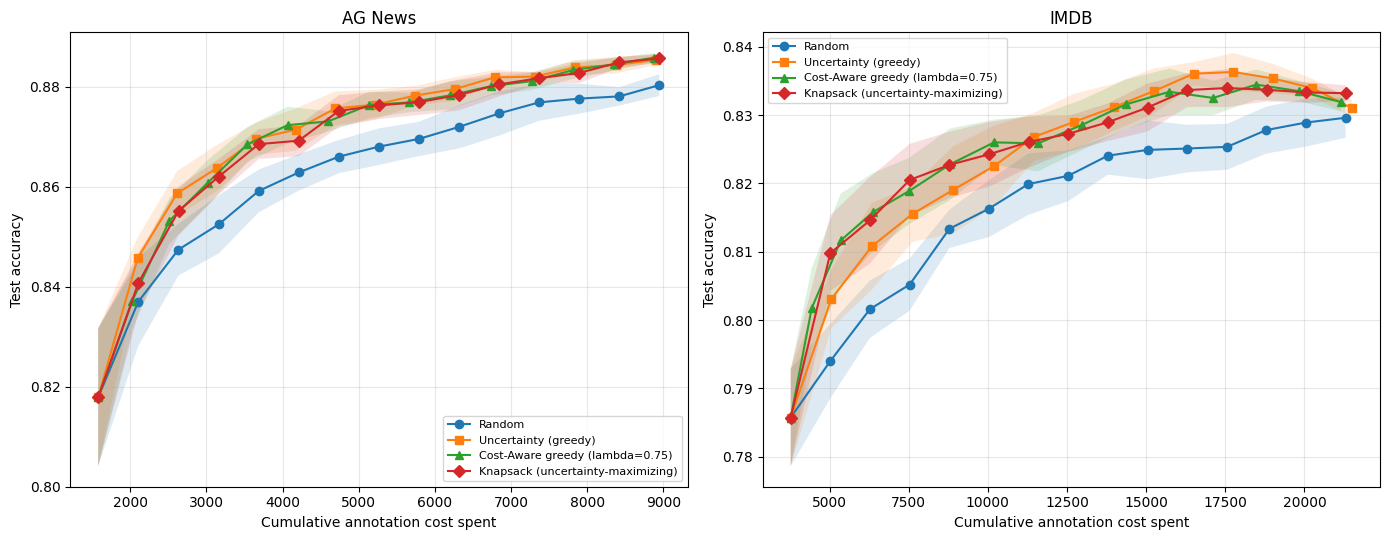

In [ ]:
"""
Knapsack-Based Active Learning vs. Greedy Cost-Aware Ranking
=================================================================
Tests the core idea behind KnapsackBALD (Dossou et al., 2026): instead of
greedily ranking unlabeled samples by a score (uncertainty/cost^lambda) and
taking the top-k, solve an actual 0-1 KNAPSACK problem each round: choose the
SUBSET of candidate samples that maximizes total uncertainty subject to a
cost budget. This can find better subsets than greedy ranking, because greedy
ranking can't "trade off" -- e.g. it might miss a combination of two cheaper,
almost-as-informative samples that together beat one expensive, slightly-more
informative one.

This does NOT reimplement full KnapsackBALD (no Bayesian/BatchBALD mutual
information estimation) -- it isolates and tests only the KNAPSACK
optimization half of their idea, using the same uncertainty scores as our
other experiments. This is an honest partial comparison, not a claim to
replicate their full method.

Four strategies compared:
    1. Random sampling
    2. Uncertainty sampling (greedy, ignores cost)
    3. Cost-Aware greedy (lambda=0.75 -- our best from earlier experiments)
    4. Knapsack (uncertainty-maximizing subset selection under a cost budget)

Run:
    python al_knapsack.py

Output:
    - knapsack_curve.png
    - knapsack_results.csv
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

RANDOM_SEED = 42

BASE_COST = 1.0
LENGTH_FACTOR = 0.02
BEST_LAMBDA = 0.75
N_SEEDS = 10  # increased from 5 for tighter confidence intervals, matching
              # the rigor used in the controlled cost-variance experiment
N_ROUNDS = 15
MAX_TRAIN = 6000
MAX_TEST = 2000

# Knapsack-specific settings
N_CANDIDATES_MULTIPLIER = 5  # restrict knapsack to top-K*batch_size most
                              # uncertain samples each round -- keeps the DP
                              # tractable (full-pool knapsack would be too slow)
COST_PRECISION = 10          # discretize cost to nearest 1/COST_PRECISION
                              # (0.1 units) so the DP has an integer capacity


def load_dataset_safe(hf_name, text_field="text", label_field="label",
                       max_train=MAX_TRAIN, max_test=MAX_TEST, max_words=200):
    try:
        from datasets import load_dataset
        ds = load_dataset(hf_name)
        train_split = ds["train"].shuffle(seed=RANDOM_SEED)
        test_split = ds["test"].shuffle(seed=RANDOM_SEED)

        def clip(texts):
            return [" ".join(t.split()[:max_words]) for t in texts]

        train_texts = clip(train_split[text_field][:max_train])
        train_labels = train_split[label_field][:max_train]
        test_texts = clip(test_split[text_field][:max_test])
        test_labels = test_split[label_field][:max_test]
        print(f"Loaded real {hf_name}: {len(train_texts)} train / {len(test_texts)} test "
              f"(classes present in train: {sorted(set(train_labels))})")
        return train_texts, train_labels, test_texts, test_labels
    except Exception as e:
        print(f"[!] Could not download {hf_name} ({e}).")
        print("[!] Falling back to SYNTHETIC data so you can test the pipeline offline.")
        print("[!] Run this script on your own machine / Colab with internet for real results.\n")
        return generate_synthetic_dataset(max_train, max_test)


def generate_synthetic_dataset(n_train, n_test):
    topics = {
        0: ["stock market rises", "company earnings report", "economy grows this quarter", "bank interest rates"],
        1: ["team wins championship", "player scores goal", "olympic athlete trains", "football match tonight"],
        2: ["new smartphone released", "software update improves", "tech company launches product", "computer chip design"],
        3: ["election results announced", "government passes law", "president gives speech", "international summit held"],
    }
    def sample(n):
        texts, labels = [], []
        for _ in range(n):
            label = np.random.randint(0, 4)
            base = np.random.choice(topics[label])
            noise = " ".join(np.random.choice(
                ["today", "yesterday", "reports say", "officials confirm", "sources indicate"],
                size=np.random.randint(1, 8)))
            texts.append(f"{base} {noise}")
            labels.append(label)
        return texts, labels
    train_texts, train_labels = sample(n_train)
    test_texts, test_labels = sample(n_test)
    return train_texts, train_labels, test_texts, test_labels


def compute_costs(texts):
    return np.array([BASE_COST + LENGTH_FACTOR * len(t.split()) for t in texts])


def vectorize(train_texts, test_texts):
    vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    return X_train, X_test


def solve_knapsack(values, costs, budget_units):
    """
    Standard 0-1 knapsack via dynamic programming (space-optimized, O(n*budget)).
    values: informativeness (uncertainty) of each candidate -- to maximize
    costs: integer cost of each candidate (already discretized)
    budget_units: integer total budget
    Returns: list of selected candidate indices (into the `values`/`costs` arrays).
    """
    n = len(values)
    # dp[c] = best total value achievable with total cost exactly <= c
    dp = np.zeros(budget_units + 1)
    # choice[i][c] = True if item i is taken in the optimal solution for budget c
    choice = np.zeros((n, budget_units + 1), dtype=bool)

    for i in range(n):
        c_i = costs[i]
        v_i = values[i]
        if c_i > budget_units:
            continue
        # iterate capacity backwards so each item is only used once (0-1 knapsack)
        for c in range(budget_units, c_i - 1, -1):
            candidate = dp[c - c_i] + v_i
            if candidate > dp[c]:
                dp[c] = candidate
                choice[i, c] = True

    # backtrack to find which items were selected
    selected = []
    c = budget_units
    for i in range(n - 1, -1, -1):
        if choice[i, c]:
            selected.append(i)
            c -= costs[i]
    return selected


def run_strategy(X_train, y_train, X_test, y_test, costs, batch_size, n_rounds,
                  seed_size, strategy="random", cost_lambda=None):
    n_total = X_train.shape[0]
    all_idx = np.arange(n_total)
    np.random.shuffle(all_idx)

    labeled_idx = list(all_idx[:seed_size])
    unlabeled_idx = list(all_idx[seed_size:])

    accuracies, cum_cost = [], []
    total_cost = costs[labeled_idx].sum()
    mean_cost = costs.mean()

    for r in range(n_rounds):
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train[labeled_idx], np.array(y_train)[labeled_idx])

        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        accuracies.append(acc)
        cum_cost.append(total_cost)

        if not unlabeled_idx:
            break

        if strategy == "random":
            n_pick = min(batch_size, len(unlabeled_idx))
            pick_idx = list(np.random.choice(unlabeled_idx, size=n_pick, replace=False))

        elif strategy == "knapsack":
            probs = clf.predict_proba(X_train[unlabeled_idx])
            uncertainty = 1 - probs.max(axis=1)

            # Restrict to top candidates by uncertainty to keep the DP tractable
            n_candidates = min(len(unlabeled_idx), batch_size * N_CANDIDATES_MULTIPLIER)
            top_order = np.argsort(-uncertainty)[:n_candidates]
            candidate_global_idx = [unlabeled_idx[i] for i in top_order]
            candidate_values = uncertainty[top_order]
            candidate_costs_raw = costs[candidate_global_idx]
            candidate_costs_int = np.round(candidate_costs_raw * COST_PRECISION).astype(int)
            candidate_costs_int = np.maximum(candidate_costs_int, 1)  # avoid zero-cost items

            # Budget = same total cost as picking batch_size average-cost items,
            # so the comparison is apples-to-apples with the greedy strategies.
            budget_units = int(round(batch_size * mean_cost * COST_PRECISION))

            selected_local = solve_knapsack(candidate_values, candidate_costs_int, budget_units)
            pick_idx = [candidate_global_idx[i] for i in selected_local]

            if not pick_idx:  # fallback safety net -- budget too small for any candidate
                n_pick = min(batch_size, len(unlabeled_idx))
                pick_idx = [unlabeled_idx[i] for i in top_order[:n_pick]]

        else:  # "uncertainty" or "cost_aware" (greedy ranking, same as before)
            probs = clf.predict_proba(X_train[unlabeled_idx])
            uncertainty = 1 - probs.max(axis=1)
            if cost_lambda:
                sample_costs = costs[unlabeled_idx]
                score = uncertainty / np.power(sample_costs, cost_lambda)
            else:
                score = uncertainty
            n_pick = min(batch_size, len(unlabeled_idx))
            order = np.argsort(-score)[:n_pick]
            pick_idx = [unlabeled_idx[i] for i in order]

        labeled_idx.extend(pick_idx)
        total_cost += costs[pick_idx].sum()
        pick_set = set(pick_idx)
        unlabeled_idx = [i for i in unlabeled_idx if i not in pick_set]

    return cum_cost, accuracies


def cost_to_target(cost_mean, acc_mean, target):
    return next((c for c, a in zip(cost_mean, acc_mean) if a >= target), None)


def bootstrap_ci(values, n_bootstrap=10000, ci=95, seed=0):
    """
    Bootstrap confidence interval for the mean of a small sample of per-seed
    values. Resamples with replacement many times and takes percentiles --
    doesn't assume normality, appropriate for small seed counts.
    Returns (mean, ci_low, ci_high).
    """
    values = np.array([v for v in values if v is not None])
    if len(values) < 2:
        return (values[0] if len(values) else None, None, None)
    rng = np.random.default_rng(seed)
    boot_means = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    lo_pct, hi_pct = (100 - ci) / 2, 100 - (100 - ci) / 2
    return values.mean(), np.percentile(boot_means, lo_pct), np.percentile(boot_means, hi_pct)


def run_on_domain(domain_name, hf_name):
    train_texts, train_labels, test_texts, test_labels = load_dataset_safe(hf_name)
    X_train, X_test = vectorize(train_texts, test_texts)
    costs = compute_costs(train_texts)

    batch_size = max(50, X_train.shape[0] // 20)
    seed_size = batch_size * 3

    strategies = {
        "Random": ("random", None),
        "Uncertainty (greedy)": ("uncertainty", None),
        f"Cost-Aware greedy (lambda={BEST_LAMBDA})": ("uncertainty", BEST_LAMBDA),
        "Knapsack (uncertainty-maximizing)": ("knapsack", None),
    }

    raw_runs = {s: [] for s in strategies}
    for seed in range(N_SEEDS):
        print(f"\n=== [{domain_name}] Seed {seed + 1}/{N_SEEDS} ===")
        for sname, (strat, lam) in strategies.items():
            np.random.seed(RANDOM_SEED + seed)
            print(f"  Running {sname}...")
            cum_cost, acc = run_strategy(
                X_train, train_labels, X_test, test_labels, costs,
                batch_size, N_ROUNDS, seed_size, strategy=strat, cost_lambda=lam)
            raw_runs[sname].append((np.array(cum_cost), np.array(acc)))

    aggregated = {}
    for sname, runs in raw_runs.items():
        min_len = min(len(a) for _, a in runs)
        accs = np.array([a[:min_len] for _, a in runs])
        costs_arr = np.array([c[:min_len] for c, _ in runs])
        aggregated[sname] = {
            "cost_mean": costs_arr.mean(axis=0),
            "acc_mean": accs.mean(axis=0),
            "acc_std": accs.std(axis=0),
        }

    peak = max(v["acc_mean"].max() for v in aggregated.values())
    target = 0.98 * peak
    print(f"\n[{domain_name}] Cost needed to reach {target:.2%} accuracy (98% of peak {peak:.2%}):")
    cost_needed = {}
    for sname, v in aggregated.items():
        needed = next((c for c, a in zip(v["cost_mean"], v["acc_mean"]) if a >= target), None)
        cost_needed[sname] = needed
        print(f"  {sname:<38}: {needed}")

    baseline = cost_needed.get("Random")
    print()
    for sname, needed in cost_needed.items():
        if sname == "Random" or needed is None or baseline is None:
            continue
        savings = (1 - needed / baseline) * 100
        print(f"  --> [{domain_name}] {sname} saves {savings:.1f}% of budget vs random")

    # --- Per-seed PAIRED confidence intervals ---
    # The aggregate-curve numbers above are single point estimates with no
    # sense of spread. Compute cost-to-target separately for each seed's own
    # curve (paired: same seed's data for every strategy), then bootstrap a
    # 95% CI over those per-seed percentages -- addresses "is this headline
    # number statistically stable, or could it be noise?"
    uncertainty_key = "Uncertainty (greedy)"
    cost_aware_key = f"Cost-Aware greedy (lambda={BEST_LAMBDA})"
    knapsack_key = "Knapsack (uncertainty-maximizing)"

    per_seed_knap_vs_unc, per_seed_ca_vs_unc, per_seed_unc_vs_random = [], [], []
    for seed_i in range(N_SEEDS):
        seed_cost_needed = {}
        for sname, runs in raw_runs.items():
            cum_cost, acc = runs[seed_i]
            seed_cost_needed[sname] = cost_to_target(cum_cost, acc, target)
        r = seed_cost_needed.get("Random")
        u = seed_cost_needed.get(uncertainty_key)
        ca = seed_cost_needed.get(cost_aware_key)
        k = seed_cost_needed.get(knapsack_key)
        if u and k:
            per_seed_knap_vs_unc.append((1 - k / u) * 100)
        if u and ca:
            per_seed_ca_vs_unc.append((1 - ca / u) * 100)
        if r and u:
            per_seed_unc_vs_random.append((1 - u / r) * 100)

    unc_mean, unc_lo, unc_hi = bootstrap_ci(per_seed_unc_vs_random, seed=RANDOM_SEED)
    knap_mean, knap_lo, knap_hi = bootstrap_ci(per_seed_knap_vs_unc, seed=RANDOM_SEED)
    ca_mean, ca_lo, ca_hi = bootstrap_ci(per_seed_ca_vs_unc, seed=RANDOM_SEED)

    print(f"\n  [{domain_name}] Per-seed paired results (n={N_SEEDS} seeds), mean [95% bootstrap CI]:")
    if unc_mean is not None:
        print(f"    Uncertainty vs Random:      {unc_mean:+.1f}% [{unc_lo:+.1f}%, {unc_hi:+.1f}%]")
    if knap_mean is not None:
        print(f"    Knapsack vs Uncertainty:    {knap_mean:+.1f}% [{knap_lo:+.1f}%, {knap_hi:+.1f}%]")
    if ca_mean is not None:
        print(f"    Cost-Aware vs Uncertainty:  {ca_mean:+.1f}% [{ca_lo:+.1f}%, {ca_hi:+.1f}%]")

    cost_needed["_ci"] = {
        "knapsack_vs_uncertainty": (knap_mean, knap_lo, knap_hi),
        "costaware_vs_uncertainty": (ca_mean, ca_lo, ca_hi),
        "uncertainty_vs_random": (unc_mean, unc_lo, unc_hi),
    }

    return aggregated, cost_needed


def main():
    domains = {
        "AG News": "fancyzhx/ag_news",
        "IMDB": "stanfordnlp/imdb",
    }

    all_aggregated = {}
    all_cost_needed = {}
    for domain_name, hf_name in domains.items():
        aggregated, cost_needed = run_on_domain(domain_name, hf_name)
        all_aggregated[domain_name] = aggregated
        all_cost_needed[domain_name] = cost_needed

    # Save CSV (both domains)
    df_dict = {}
    for domain_name, aggregated in all_aggregated.items():
        for sname, v in aggregated.items():
            key = "".join(c if c.isalnum() else "_" for c in f"{domain_name}_{sname}")
            df_dict[f"cost_{key}"] = pd.Series(v["cost_mean"])
            df_dict[f"acc_mean_{key}"] = pd.Series(v["acc_mean"])
            df_dict[f"acc_std_{key}"] = pd.Series(v["acc_std"])
    pd.DataFrame(df_dict).to_csv("knapsack_results.csv", index=False)
    print("\nSaved raw results to knapsack_results.csv")

    # Side-by-side plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    markers = ["o", "s", "^", "D"]
    for ax, (domain_name, aggregated) in zip(axes, all_aggregated.items()):
        for (sname, v), m in zip(aggregated.items(), markers):
            ax.plot(v["cost_mean"], v["acc_mean"], marker=m, label=sname)
            ax.fill_between(v["cost_mean"], v["acc_mean"] - v["acc_std"],
                             v["acc_mean"] + v["acc_std"], alpha=0.15)
        ax.set_xlabel("Cumulative annotation cost spent")
        ax.set_ylabel("Test accuracy")
        ax.set_title(domain_name)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("knapsack_curve.png", dpi=150)
    print("Saved plot to knapsack_curve.png")

    # Final comparison, using the per-seed paired bootstrap CIs computed in
    # run_on_domain (more rigorous than a single aggregate-curve point estimate)
    print(f"\n=== KEY COMPARISON FOR THE PAPER (mean [95% bootstrap CI], n={N_SEEDS} seeds) ===")
    for domain_name in domains:
        ci = all_cost_needed[domain_name].get("_ci", {})
        unc = ci.get("uncertainty_vs_random")
        knap = ci.get("knapsack_vs_uncertainty")
        ca = ci.get("costaware_vs_uncertainty")
        if unc and unc[0] is not None:
            print(f"[{domain_name}] Uncertainty vs Random:     {unc[0]:+.1f}% [{unc[1]:+.1f}%, {unc[2]:+.1f}%]")
        if knap and knap[0] is not None:
            sig = "SIGNIFICANT" if (knap[1] is not None and knap[1] > 0) or (knap[2] is not None and knap[2] < 0) else "not significant (CI includes 0)"
            print(f"[{domain_name}] Knapsack vs Uncertainty:   {knap[0]:+.1f}% [{knap[1]:+.1f}%, {knap[2]:+.1f}%]  -- {sig}")
        if ca and ca[0] is not None:
            sig = "SIGNIFICANT" if (ca[1] is not None and ca[1] > 0) or (ca[2] is not None and ca[2] < 0) else "not significant (CI includes 0)"
            print(f"[{domain_name}] Cost-Aware vs Uncertainty: {ca[0]:+.1f}% [{ca[1]:+.1f}%, {ca[2]:+.1f}%]  -- {sig}")


if __name__ == "__main__":
    main()

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Loaded real AG News: 6000 train / 2000 test
Simulated cost per sample: min=1.22, max=3.68, mean=1.78

=== Seed 1/10 ===

Diagnostic: correlation between cost and uncertainty = -0.099
  --> Cost and informativeness are roughly UNCORRELATED.
      Cost-aware selection should be close to a free efficiency gain.

=== Seed 2/10 ===

Diagnostic: correlation between cost and uncertainty = -0.107
  --> Cost and informativeness are roughly UNCORRELATED.
      Cost-aware selection should be close to a free efficiency gain.

=== Seed 3/10 ===

Diagnostic: correlation between cost and uncertainty = -0.105
  --> Cost and informativeness are roughly UNCORRELATED.
      Cost-aware selection should be close to a free efficiency gain.

=== Seed 4/10 ===

Diagnostic: correlation between cost and uncertainty = -0.110
  --> Cost and informativeness are roughly UNCORRELATED.
      Cost-aware selection should be close to a free efficiency gain.

=== Seed 5/10 ===

Diagnostic: correlation between cost and un

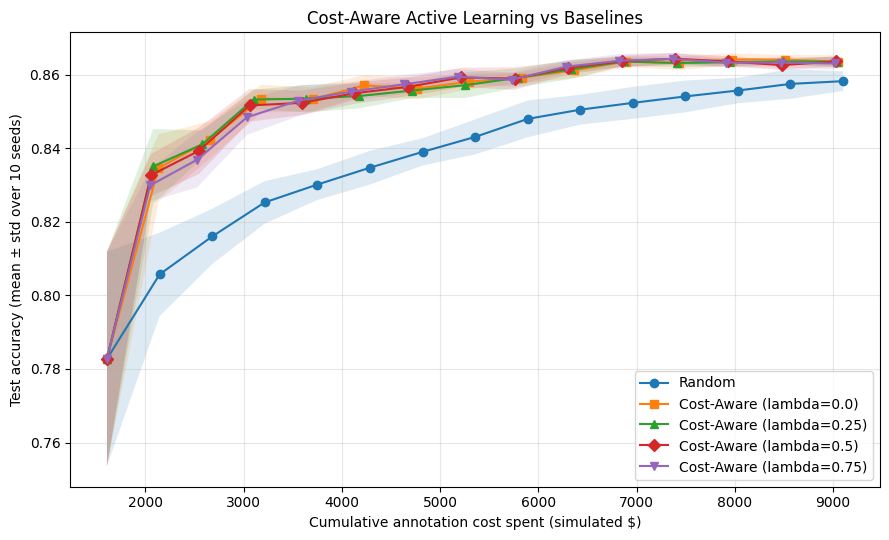

In [ ]:
"""
Cost-Aware Active Learning — Extension of al_experiment.py
=============================================================
Adds a third strategy: COST-AWARE active learning, which selects samples
by uncertainty-per-dollar rather than raw uncertainty. This is the core
novel contribution for the paper: most AL research optimizes accuracy per
LABEL, but real annotation budgets are measured in MONEY, and not all
samples cost the same to label.

Cost model (simulated, documented assumption for the paper):
    cost(sample) = BASE_COST + LENGTH_FACTOR * (number of words in the text)
    Rationale: longer articles take an annotator longer to read and judge,
    so they cost more to label. This is a standard, defensible proxy used
    in annotation-cost literature when real per-sample cost logs aren't
    available.

Three strategies compared, all plotted against CUMULATIVE COST SPENT
(not just label count) on the x-axis:
    1. Random sampling
    2. Uncertainty sampling (ignores cost)
    3. Cost-aware sampling (uncertainty / cost ratio)

Run:
    python al_cost_aware.py

Output:
    - cost_aware_curve.png
    - cost_aware_results.csv
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

BASE_COST = 1.0        # flat cost per sample (e.g. minimum annotator time)
LENGTH_FACTOR = 0.02    # extra cost per word


def load_ag_news(max_train=6000, max_test=2000):
    try:
        from datasets import load_dataset
        ds = load_dataset("fancyzhx/ag_news")
        train_texts = ds["train"]["text"][:max_train]
        train_labels = ds["train"]["label"][:max_train]
        test_texts = ds["test"]["text"][:max_test]
        test_labels = ds["test"]["label"][:max_test]
        print(f"Loaded real AG News: {len(train_texts)} train / {len(test_texts)} test")
        return train_texts, train_labels, test_texts, test_labels
    except Exception as e:
        print(f"[!] Could not download AG News ({e}).")
        print("[!] Falling back to SYNTHETIC data so you can test the pipeline offline.")
        print("[!] Run this script on your own machine / Colab with internet for real results.\n")
        return generate_synthetic_dataset(max_train, max_test)


def generate_synthetic_dataset(n_train, n_test):
    topics = {
        0: ["stock market rises", "company earnings report", "economy grows this quarter", "bank interest rates"],
        1: ["team wins championship", "player scores goal", "olympic athlete trains", "football match tonight"],
        2: ["new smartphone released", "software update improves", "tech company launches product", "computer chip design"],
        3: ["election results announced", "government passes law", "president gives speech", "international summit held"],
    }
    def sample(n):
        texts, labels = [], []
        for _ in range(n):
            label = np.random.randint(0, 4)
            base = np.random.choice(topics[label])
            noise = " ".join(np.random.choice(
                ["today", "yesterday", "reports say", "officials confirm", "sources indicate"],
                size=np.random.randint(1, 8)))
            texts.append(f"{base} {noise}")
            labels.append(label)
        return texts, labels
    train_texts, train_labels = sample(n_train)
    test_texts, test_labels = sample(n_test)
    return train_texts, train_labels, test_texts, test_labels


def compute_costs(texts):
    """Simulated per-sample labeling cost based on text length."""
    return np.array([BASE_COST + LENGTH_FACTOR * len(t.split()) for t in texts])


def vectorize(train_texts, test_texts):
    vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    return X_train, X_test


def run_strategy(X_train, y_train, X_test, y_test, costs, batch_size, n_rounds,
                  seed_size, strategy="random", cost_lambda=1.0):
    """
    Unified loop for all three strategies.
    strategy: "random" | "uncertainty" | "cost_aware"
    cost_lambda: exponent controlling how strongly cost is penalized in
        cost_aware scoring: score = uncertainty / (cost ** cost_lambda).
        lambda=0 reduces to plain uncertainty sampling (cost ignored).
        lambda=1 is a full cost-per-dollar tradeoff (can overcorrect if
        cost correlates with informativeness, as AG News shows).
    Tracks cumulative COST spent, not just label count.
    """
    n_total = X_train.shape[0]
    all_idx = np.arange(n_total)
    np.random.shuffle(all_idx)

    labeled_idx = list(all_idx[:seed_size])
    unlabeled_idx = list(all_idx[seed_size:])

    accuracies, cum_cost, n_labels = [], [], []
    total_cost = costs[labeled_idx].sum()

    for r in range(n_rounds):
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train[labeled_idx], np.array(y_train)[labeled_idx])

        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        accuracies.append(acc)
        cum_cost.append(total_cost)
        n_labels.append(len(labeled_idx))

        if not unlabeled_idx:
            break

        if strategy == "random":
            n_pick = min(batch_size, len(unlabeled_idx))
            pick_idx = list(np.random.choice(unlabeled_idx, size=n_pick, replace=False))

        else:
            probs = clf.predict_proba(X_train[unlabeled_idx])
            uncertainty = 1 - probs.max(axis=1)

            if strategy == "uncertainty":
                score = uncertainty
            elif strategy == "cost_aware":
                # Value = uncertainty per unit cost, with a tunable exponent.
                # lambda controls how aggressively cost is penalized.
                sample_costs = costs[unlabeled_idx]
                score = uncertainty / np.power(sample_costs, cost_lambda)
            else:
                raise ValueError(f"Unknown strategy: {strategy}")

            n_pick = min(batch_size, len(unlabeled_idx))
            order = np.argsort(-score)[:n_pick]
            pick_idx = [unlabeled_idx[i] for i in order]

        labeled_idx.extend(pick_idx)
        total_cost += costs[pick_idx].sum()
        pick_set = set(pick_idx)
        unlabeled_idx = [i for i in unlabeled_idx if i not in pick_set]

    return cum_cost, accuracies, n_labels


def diagnose_cost_informativeness_correlation(X_train, y_train, costs, seed_size):
    """
    Checks whether cost (text length) correlates with informativeness
    (uncertainty). If they're positively correlated, naive cost-weighting
    will systematically avoid the most useful samples -- explaining why
    cost-aware can underperform plain uncertainty sampling.
    """
    idx = np.arange(X_train.shape[0])
    np.random.shuffle(idx)
    seed_idx = list(idx[:seed_size])
    rest_idx = list(idx[seed_size:])

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train[seed_idx], np.array(y_train)[seed_idx])
    probs = clf.predict_proba(X_train[rest_idx])
    uncertainty = 1 - probs.max(axis=1)

    corr = np.corrcoef(costs[rest_idx], uncertainty)[0, 1]
    print(f"\nDiagnostic: correlation between cost and uncertainty = {corr:.3f}")
    if corr > 0.15:
        print("  --> Cost and informativeness are POSITIVELY correlated:")
        print("      expensive samples tend to be more informative.")
        print("      This explains why naive cost-weighting can hurt accuracy-per-dollar.")
    elif corr < -0.15:
        print("  --> Cost and informativeness are NEGATIVELY correlated:")
        print("      cheap samples tend to be more informative -- cost-aware")
        print("      selection should help here.")
    else:
        print("  --> Cost and informativeness are roughly UNCORRELATED.")
        print("      Cost-aware selection should be close to a free efficiency gain.")
    return corr


def cost_to_target(cost_arr, acc_arr, target):
    return next((c for c, a in zip(cost_arr, acc_arr) if a >= target), None)


def bootstrap_ci(values, n_bootstrap=10000, ci=95, seed=0):
    """
    Bootstrap confidence interval for the mean of a small sample of per-seed
    values. Resamples with replacement many times and takes percentiles --
    doesn't assume normality, appropriate for small seed counts.
    Returns (mean, ci_low, ci_high).
    """
    values = np.array([v for v in values if v is not None])
    if len(values) < 2:
        return (values[0] if len(values) else None, None, None)
    rng = np.random.default_rng(seed)
    boot_means = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    lo_pct, hi_pct = (100 - ci) / 2, 100 - (100 - ci) / 2
    return values.mean(), np.percentile(boot_means, lo_pct), np.percentile(boot_means, hi_pct)


def main():
    train_texts, train_labels, test_texts, test_labels = load_ag_news()
    X_train, X_test = vectorize(train_texts, test_texts)
    costs = compute_costs(train_texts)

    print(f"Simulated cost per sample: min={costs.min():.2f}, "
          f"max={costs.max():.2f}, mean={costs.mean():.2f}")

    batch_size = max(50, X_train.shape[0] // 20)
    n_rounds = 15
    seed_size = batch_size * 3
    N_SEEDS = 10  # increased from 5 for tighter confidence intervals, matching
                  # the rigor used elsewhere in the paper after Section 4.5's
                  # revision showed 5 seeds was not enough to trust a headline number.

    strategies = {
        "Random": ("random", None),
        "Cost-Aware (lambda=0.0)": ("cost_aware", 0.0),   # = plain uncertainty sampling
        "Cost-Aware (lambda=0.25)": ("cost_aware", 0.25),
        "Cost-Aware (lambda=0.5)": ("cost_aware", 0.5),
        "Cost-Aware (lambda=0.75)": ("cost_aware", 0.75),
        "Cost-Aware (lambda=1.0)": ("cost_aware", 1.0),
    }

    # results[name] = list of (cum_cost, accuracy) arrays, one pair per seed
    raw_runs = {name: [] for name in strategies}
    correlations = []

    for seed in range(N_SEEDS):
        print(f"\n=== Seed {seed + 1}/{N_SEEDS} ===")
        np.random.seed(RANDOM_SEED + seed)

        corr = diagnose_cost_informativeness_correlation(X_train, train_labels, costs, seed_size)
        correlations.append(corr)

        for name, (strat, lam) in strategies.items():
            np.random.seed(RANDOM_SEED + seed)  # reset so every strategy sees the SAME seed data
            kwargs = {"cost_lambda": lam} if lam is not None else {}
            cum_cost, acc, n_labels = run_strategy(
                X_train, train_labels, X_test, test_labels, costs,
                batch_size, n_rounds, seed_size, strategy=strat, **kwargs)
            raw_runs[name].append((np.array(cum_cost), np.array(acc)))

    print(f"\nMean cost/uncertainty correlation across seeds: "
          f"{np.mean(correlations):.3f} (std {np.std(correlations):.3f})")

    # Aggregate: align by ROUND INDEX (not exact cost, which varies slightly
    # per seed), then average accuracy and cost across seeds at each round.
    aggregated = {}
    for name, runs in raw_runs.items():
        min_len = min(len(acc) for _, acc in runs)
        accs = np.array([acc[:min_len] for _, acc in runs])
        costs_arr = np.array([c[:min_len] for c, _ in runs])
        aggregated[name] = {
            "cost_mean": costs_arr.mean(axis=0),
            "acc_mean": accs.mean(axis=0),
            "acc_std": accs.std(axis=0),
        }

    # Save raw results
    df_dict = {}
    for name, v in aggregated.items():
        key = "".join(c if c.isalnum() else "_" for c in name)
        df_dict[f"cost_{key}"] = pd.Series(v["cost_mean"])
        df_dict[f"accuracy_mean_{key}"] = pd.Series(v["acc_mean"])
        df_dict[f"accuracy_std_{key}"] = pd.Series(v["acc_std"])
    pd.DataFrame(df_dict).to_csv("cost_aware_results.csv", index=False)
    print("\nSaved raw results to cost_aware_results.csv")

    # Plot: accuracy vs cumulative cost spent, with shaded std band
    plt.figure(figsize=(9, 5.5))
    markers = ["o", "s", "^", "D", "v"]
    for (name, v), m in zip(aggregated.items(), markers):
        plt.plot(v["cost_mean"], v["acc_mean"], marker=m, label=name)
        plt.fill_between(v["cost_mean"], v["acc_mean"] - v["acc_std"],
                          v["acc_mean"] + v["acc_std"], alpha=0.15)
    plt.xlabel("Cumulative annotation cost spent (simulated $)")
    plt.ylabel("Test accuracy (mean \u00b1 std over {} seeds)".format(N_SEEDS))
    plt.title("Cost-Aware Active Learning vs Baselines")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("cost_aware_curve.png", dpi=150)
    print("Saved plot to cost_aware_curve.png")

    # Headline metric: cost needed to reach a near-peak accuracy target,
    # computed on the AVERAGED curves -- much more trustworthy than one run.
    peak = max(v["acc_mean"].max() for v in aggregated.values())
    target = 0.98 * peak
    print(f"\nCost needed to reach {target:.2%} accuracy (98% of peak {peak:.2%}), averaged over {N_SEEDS} seeds:")
    cost_needed = {}
    for name, v in aggregated.items():
        needed = next((c for c, a in zip(v["cost_mean"], v["acc_mean"]) if a >= target), None)
        cost_needed[name] = needed
        print(f"  {name:<28}: {needed}")

    baseline = cost_needed.get("Random")
    uncertainty_cost = cost_needed.get("Cost-Aware (lambda=0.0)")  # = plain uncertainty sampling
    print()
    for name, needed in cost_needed.items():
        if name == "Random" or needed is None or baseline is None:
            continue
        savings_vs_random = (1 - needed / baseline) * 100
        print(f"--> {name} saves {savings_vs_random:.1f}% of budget vs random (avg of {N_SEEDS} seeds)")
        if uncertainty_cost is not None and name != "Cost-Aware (lambda=0.0)":
            savings_vs_uncertainty = (1 - needed / uncertainty_cost) * 100
            print(f"    and {savings_vs_uncertainty:.1f}% vs plain uncertainty sampling (lambda=0.0)")

    # Best lambda summary -- the actual headline for the paper's ablation section
    best_name = min(
        (n for n in cost_needed if n != "Random" and cost_needed[n] is not None),
        key=lambda n: cost_needed[n],
        default=None,
    )
    if best_name:
        print(f"\nBest strategy: {best_name} (lowest cost to reach target accuracy)")

    # --- Per-seed PAIRED confidence intervals ---
    # The aggregate-curve numbers above are single point estimates. Compute
    # cost-to-target separately for each seed's own curve (paired: same
    # seed's data for every lambda value), then bootstrap a 95% CI over
    # those per-seed percentages vs random and vs plain uncertainty
    # (lambda=0.0) -- addresses whether the lambda-sweep ranking is
    # statistically stable, not just a single aggregate ordering.
    print(f"\n{'='*70}")
    print(f"Per-seed paired results (n={N_SEEDS} seeds), mean [95% bootstrap CI]:")
    print(f"{'='*70}")
    for name in strategies:
        if name == "Random":
            continue
        per_seed_vs_random, per_seed_vs_uncertainty = [], []
        for seed_i in range(N_SEEDS):
            seed_cost = {}
            for sname, runs in raw_runs.items():
                cum_cost, acc = runs[seed_i]
                seed_cost[sname] = cost_to_target(cum_cost, acc, target)
            r = seed_cost.get("Random")
            u0 = seed_cost.get("Cost-Aware (lambda=0.0)")
            v = seed_cost.get(name)
            if r and v:
                per_seed_vs_random.append((1 - v / r) * 100)
            if u0 and v and name != "Cost-Aware (lambda=0.0)":
                per_seed_vs_uncertainty.append((1 - v / u0) * 100)

        mean_r, lo_r, hi_r = bootstrap_ci(per_seed_vs_random, seed=RANDOM_SEED)
        line = f"  {name:<28} vs Random:       "
        if mean_r is not None:
            line += f"{mean_r:+.1f}% [{lo_r:+.1f}%, {hi_r:+.1f}%]"
        print(line)
        if per_seed_vs_uncertainty:
            mean_u, lo_u, hi_u = bootstrap_ci(per_seed_vs_uncertainty, seed=RANDOM_SEED)
            sig = "SIGNIFICANT" if (lo_u is not None and lo_u > 0) or (hi_u is not None and hi_u < 0) else "not significant"
            print(f"  {name:<28} vs Uncertainty:  {mean_u:+.1f}% [{lo_u:+.1f}%, {hi_u:+.1f}%]  -- {sig}")


if __name__ == "__main__":
    main()

=== Loading AG News (source domain) ===
Loaded real fancyzhx/ag_news: 6000 train / 2000 test (classes present in train: [0, 1, 2, 3])

=== Loading IMDB (target domain) ===


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

[!] Could not download stanfordnlp/imdb ((Request ID: Root=1-6a9c63ff-13804b4662a64c412bd9c18f;d3c97a6d-03f1-47d2-ac58-6c3b462e5365)

429 Too Many Requests for url: https://huggingface.co/api/datasets/stanfordnlp/imdb/tree/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/plain_text?recursive=true&expand=false.
maximum queue size reached).
[!] Falling back to SYNTHETIC data so you can test the pipeline offline.
[!] Run this script on your own machine / Colab with internet for real results.


=== Running strategies on AG News ===
Diagnostic: cost/uncertainty correlation = -0.104, cost std = 0.196, cost range = 2.720

[AG News] Cost needed to reach 86.81% accuracy (98% of peak 88.58%):
  Random                      : 5791.828
  Uncertainty (lambda=0.0)    : 3656.982000000001
  Cost-Aware (lambda=0.75)    : 3538.2640000000006
  --> Uncertainty (lambda=0.0) saves 36.9% of budget vs random on AG News
  --> Cost-Aware (lambda=0.75) saves 38.9% of budget vs random on AG News

  [AG News] Per-seed pair

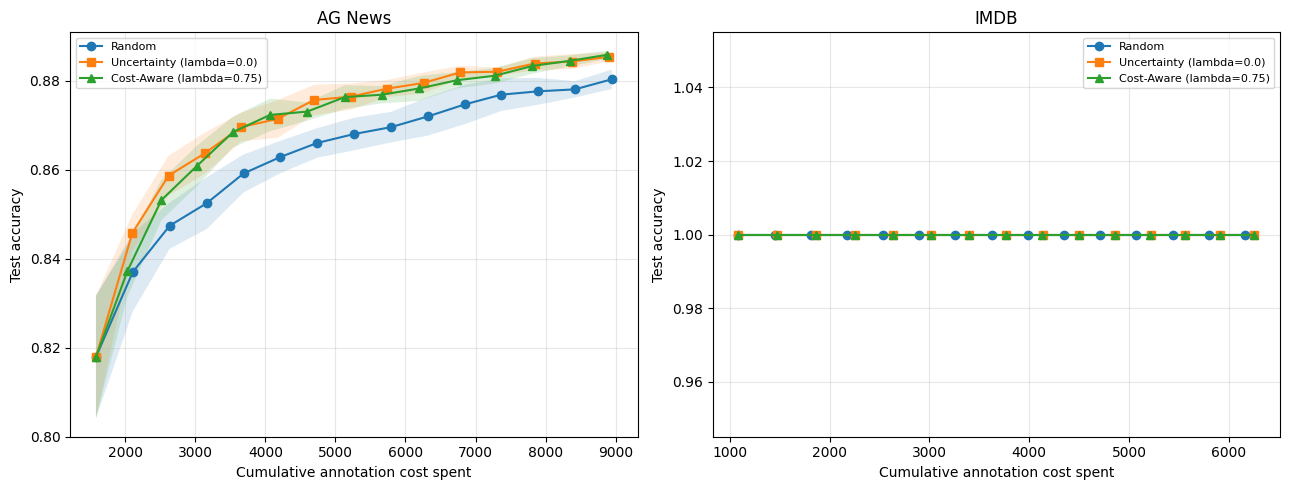

In [ ]:
"""
Domain-Transfer Generalization Test — Extension of al_cost_aware.py
=======================================================================
Tests whether the cost-aware active learning strategy that worked well on
AG News (news topic classification) ALSO works well on a different domain:
IMDB (movie review sentiment classification).

This is the "generalization" research angle: does an AL strategy tuned on
one domain transfer to another, or is it dataset-specific? We do NOT
transfer the trained classifier itself (the label spaces are different --
4-class topics vs 2-class sentiment). Instead we test whether the SAME
acquisition strategy and lambda value (found on AG News) gives a similar
efficiency advantage when applied fresh to IMDB.

Three strategies, run independently on both domains:
    1. Random sampling
    2. Uncertainty sampling (lambda=0.0)
    3. Cost-Aware sampling (lambda=0.75 -- the winner found on AG News)

Run:
    python al_domain_transfer.py

Output:
    - domain_transfer_curve.png  (side-by-side panels: AG News vs IMDB)
    - domain_transfer_results.csv
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

RANDOM_SEED = 42

BASE_COST = 1.0
LENGTH_FACTOR = 0.02

BEST_LAMBDA = 0.75  # winner found on AG News -- the value being tested for transfer
N_SEEDS = 10  # increased from 5 for tighter confidence intervals, matching
              # the rigor used elsewhere in the paper after Section 4.5's
              # revision showed 5 seeds was not enough to trust a headline number.
N_ROUNDS = 15
MAX_TRAIN = 6000
MAX_TEST = 2000


def load_dataset_safe(hf_name, text_field="text", label_field="label",
                       max_train=MAX_TRAIN, max_test=MAX_TEST, max_words=200):
    """
    Loads a Hugging Face dataset. Falls back to synthetic data if offline.
    max_words: truncate long texts (e.g. IMDB reviews) for speed -- doesn't
    change the classification task, just keeps TF-IDF/training fast.
    """
    try:
        from datasets import load_dataset
        ds = load_dataset(hf_name)
        # IMPORTANT: some HF datasets (notably IMDB) are stored in label-sorted
        # order (all negative reviews first, then all positive). Slicing the
        # first N rows without shuffling can grab only one class. Always
        # shuffle before taking a subset.
        train_split = ds["train"].shuffle(seed=RANDOM_SEED)
        test_split = ds["test"].shuffle(seed=RANDOM_SEED)

        def clip(texts):
            return [" ".join(t.split()[:max_words]) for t in texts]

        train_texts = clip(train_split[text_field][:max_train])
        train_labels = train_split[label_field][:max_train]
        test_texts = clip(test_split[text_field][:max_test])
        test_labels = test_split[label_field][:max_test]
        print(f"Loaded real {hf_name}: {len(train_texts)} train / {len(test_texts)} test "
              f"(classes present in train: {sorted(set(train_labels))})")
        return train_texts, train_labels, test_texts, test_labels
    except Exception as e:
        print(f"[!] Could not download {hf_name} ({e}).")
        print("[!] Falling back to SYNTHETIC data so you can test the pipeline offline.")
        print("[!] Run this script on your own machine / Colab with internet for real results.\n")
        return generate_synthetic_dataset(max_train, max_test)


def generate_synthetic_dataset(n_train, n_test, n_classes=2):
    vocab = {
        0: ["boring slow disappointing", "waste of time", "poorly written weak plot"],
        1: ["brilliant amazing loved it", "fantastic performance", "highly recommend great film"],
    }
    def sample(n):
        texts, labels = [], []
        for _ in range(n):
            label = np.random.randint(0, n_classes)
            base = np.random.choice(vocab[label])
            noise = " ".join(np.random.choice(
                ["really", "honestly", "overall", "in my opinion", "definitely"],
                size=np.random.randint(1, 10)))
            texts.append(f"{base} {noise}")
            labels.append(label)
        return texts, labels
    train_texts, train_labels = sample(n_train)
    test_texts, test_labels = sample(n_test)
    return train_texts, train_labels, test_texts, test_labels


def compute_costs(texts):
    return np.array([BASE_COST + LENGTH_FACTOR * len(t.split()) for t in texts])


def diagnose_cost_informativeness_correlation(X_train, y_train, costs, seed_size):
    """Same diagnostic as al_cost_aware.py: checks whether cost (text length)
    correlates with informativeness (uncertainty). Run per-domain here so we
    can compare AG News vs IMDB directly."""
    idx = np.arange(X_train.shape[0])
    np.random.shuffle(idx)
    seed_idx = list(idx[:seed_size])
    rest_idx = list(idx[seed_size:])

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train[seed_idx], np.array(y_train)[seed_idx])
    probs = clf.predict_proba(X_train[rest_idx])
    uncertainty = 1 - probs.max(axis=1)

    corr = np.corrcoef(costs[rest_idx], uncertainty)[0, 1]
    cost_std = costs[rest_idx].std()
    cost_range = costs[rest_idx].max() - costs[rest_idx].min()
    print(f"Diagnostic: cost/uncertainty correlation = {corr:.3f}, "
          f"cost std = {cost_std:.3f}, cost range = {cost_range:.3f}")
    return corr, cost_std


def vectorize(train_texts, test_texts):
    vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    return X_train, X_test


def run_strategy(X_train, y_train, X_test, y_test, costs, batch_size, n_rounds,
                  seed_size, strategy="random", cost_lambda=None):
    n_total = X_train.shape[0]
    all_idx = np.arange(n_total)
    np.random.shuffle(all_idx)

    labeled_idx = list(all_idx[:seed_size])
    unlabeled_idx = list(all_idx[seed_size:])

    accuracies, cum_cost = [], []
    total_cost = costs[labeled_idx].sum()

    for r in range(n_rounds):
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train[labeled_idx], np.array(y_train)[labeled_idx])

        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        accuracies.append(acc)
        cum_cost.append(total_cost)

        if not unlabeled_idx:
            break

        if strategy == "random":
            n_pick = min(batch_size, len(unlabeled_idx))
            pick_idx = list(np.random.choice(unlabeled_idx, size=n_pick, replace=False))
        else:
            probs = clf.predict_proba(X_train[unlabeled_idx])
            uncertainty = 1 - probs.max(axis=1)
            if cost_lambda:
                sample_costs = costs[unlabeled_idx]
                score = uncertainty / np.power(sample_costs, cost_lambda)
            else:
                score = uncertainty
            n_pick = min(batch_size, len(unlabeled_idx))
            order = np.argsort(-score)[:n_pick]
            pick_idx = [unlabeled_idx[i] for i in order]

        labeled_idx.extend(pick_idx)
        total_cost += costs[pick_idx].sum()
        pick_set = set(pick_idx)
        unlabeled_idx = [i for i in unlabeled_idx if i not in pick_set]

    return cum_cost, accuracies


def cost_to_target(cost_arr, acc_arr, target):
    return next((c for c, a in zip(cost_arr, acc_arr) if a >= target), None)


def bootstrap_ci(values, n_bootstrap=10000, ci=95, seed=0):
    """Bootstrap confidence interval for the mean of a small per-seed sample."""
    values = np.array([v for v in values if v is not None])
    if len(values) < 2:
        return (values[0] if len(values) else None, None, None)
    rng = np.random.default_rng(seed)
    boot_means = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    lo_pct, hi_pct = (100 - ci) / 2, 100 - (100 - ci) / 2
    return values.mean(), np.percentile(boot_means, lo_pct), np.percentile(boot_means, hi_pct)


def run_domain(name, train_texts, train_labels, test_texts, test_labels):
    """Runs all 3 strategies across N_SEEDS on one domain, returns aggregated results."""
    X_train, X_test = vectorize(train_texts, test_texts)
    costs = compute_costs(train_texts)
    batch_size = max(50, X_train.shape[0] // 20)
    seed_size = batch_size * 3

    # Diagnose cost/informativeness relationship for this domain -- explains
    # WHY cost-aware sampling might help more or less here than elsewhere.
    diagnose_cost_informativeness_correlation(X_train, train_labels, costs, seed_size)

    strategies = {
        "Random": ("random", None),
        "Uncertainty (lambda=0.0)": ("uncertainty", None),
        f"Cost-Aware (lambda={BEST_LAMBDA})": ("uncertainty", BEST_LAMBDA),
    }

    raw_runs = {s: [] for s in strategies}
    for seed in range(N_SEEDS):
        for sname, (strat, lam) in strategies.items():
            np.random.seed(RANDOM_SEED + seed)
            cum_cost, acc = run_strategy(
                X_train, train_labels, X_test, test_labels, costs,
                batch_size, N_ROUNDS, seed_size, strategy=strat, cost_lambda=lam)
            raw_runs[sname].append((np.array(cum_cost), np.array(acc)))

    aggregated = {}
    for sname, runs in raw_runs.items():
        min_len = min(len(a) for _, a in runs)
        accs = np.array([a[:min_len] for _, a in runs])
        costs_arr = np.array([c[:min_len] for c, _ in runs])
        aggregated[sname] = {
            "cost_mean": costs_arr.mean(axis=0),
            "acc_mean": accs.mean(axis=0),
            "acc_std": accs.std(axis=0),
        }

    # Savings vs random at 98%-of-peak target
    peak = max(v["acc_mean"].max() for v in aggregated.values())
    target = 0.98 * peak
    cost_needed = {}
    for sname, v in aggregated.items():
        needed = next((c for c, a in zip(v["cost_mean"], v["acc_mean"]) if a >= target), None)
        cost_needed[sname] = needed

    print(f"\n[{name}] Cost needed to reach {target:.2%} accuracy (98% of peak {peak:.2%}):")
    for sname, needed in cost_needed.items():
        print(f"  {sname:<28}: {needed}")
    baseline = cost_needed.get("Random")
    if baseline:
        for sname, needed in cost_needed.items():
            if sname == "Random" or needed is None:
                continue
            savings = (1 - needed / baseline) * 100
            print(f"  --> {sname} saves {savings:.1f}% of budget vs random on {name}")

    # --- Per-seed PAIRED confidence intervals ---
    uncertainty_key = "Uncertainty (lambda=0.0)"
    cost_aware_key = f"Cost-Aware (lambda={BEST_LAMBDA})"
    per_seed_unc_vs_random, per_seed_ca_vs_unc = [], []
    for seed_i in range(N_SEEDS):
        seed_cost = {}
        for sname, runs in raw_runs.items():
            cum_cost, acc = runs[seed_i]
            seed_cost[sname] = cost_to_target(cum_cost, acc, target)
        r = seed_cost.get("Random")
        u = seed_cost.get(uncertainty_key)
        ca = seed_cost.get(cost_aware_key)
        if r and u:
            per_seed_unc_vs_random.append((1 - u / r) * 100)
        if u and ca:
            per_seed_ca_vs_unc.append((1 - ca / u) * 100)

    unc_mean, unc_lo, unc_hi = bootstrap_ci(per_seed_unc_vs_random, seed=RANDOM_SEED)
    ca_mean, ca_lo, ca_hi = bootstrap_ci(per_seed_ca_vs_unc, seed=RANDOM_SEED)
    print(f"\n  [{name}] Per-seed paired results (n={N_SEEDS} seeds), mean [95% bootstrap CI]:")
    if unc_mean is not None:
        print(f"    Uncertainty vs Random:      {unc_mean:+.1f}% [{unc_lo:+.1f}%, {unc_hi:+.1f}%]")
    if ca_mean is not None:
        sig = "SIGNIFICANT" if (ca_lo is not None and ca_lo > 0) or (ca_hi is not None and ca_hi < 0) else "not significant"
        print(f"    Cost-Aware vs Uncertainty:  {ca_mean:+.1f}% [{ca_lo:+.1f}%, {ca_hi:+.1f}%]  -- {sig}")

    cost_needed["_ci"] = {
        "uncertainty_vs_random": (unc_mean, unc_lo, unc_hi),
        "costaware_vs_uncertainty": (ca_mean, ca_lo, ca_hi),
    }

    return aggregated, cost_needed


def main():
    print("=== Loading AG News (source domain) ===")
    ag_train_t, ag_train_l, ag_test_t, ag_test_l = load_dataset_safe("fancyzhx/ag_news")

    print("\n=== Loading IMDB (target domain) ===")
    imdb_train_t, imdb_train_l, imdb_test_t, imdb_test_l = load_dataset_safe("stanfordnlp/imdb")

    print("\n=== Running strategies on AG News ===")
    ag_results, ag_cost_needed = run_domain("AG News", ag_train_t, ag_train_l, ag_test_t, ag_test_l)

    print("\n=== Running strategies on IMDB ===")
    imdb_results, imdb_cost_needed = run_domain("IMDB", imdb_train_t, imdb_train_l, imdb_test_t, imdb_test_l)

    # Side-by-side plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, (domain_name, results) in zip(axes, [("AG News", ag_results), ("IMDB", imdb_results)]):
        markers = ["o", "s", "^"]
        for (sname, v), m in zip(results.items(), markers):
            ax.plot(v["cost_mean"], v["acc_mean"], marker=m, label=sname)
            ax.fill_between(v["cost_mean"], v["acc_mean"] - v["acc_std"],
                             v["acc_mean"] + v["acc_std"], alpha=0.15)
        ax.set_xlabel("Cumulative annotation cost spent")
        ax.set_ylabel("Test accuracy")
        ax.set_title(domain_name)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("domain_transfer_curve.png", dpi=150)
    print("\nSaved plot to domain_transfer_curve.png")

    # Save CSV
    df_dict = {}
    for domain_name, results in [("AGNews", ag_results), ("IMDB", imdb_results)]:
        for sname, v in results.items():
            key = "".join(c if c.isalnum() else "_" for c in f"{domain_name}_{sname}")
            df_dict[f"cost_{key}"] = pd.Series(v["cost_mean"])
            df_dict[f"acc_{key}"] = pd.Series(v["acc_mean"])
    pd.DataFrame(df_dict).to_csv("domain_transfer_results.csv", index=False)
    print("Saved raw results to domain_transfer_results.csv")

    # Final generalization verdict
    print("\n=== GENERALIZATION SUMMARY ===")
    ag_baseline = ag_cost_needed.get("Random")
    imdb_baseline = imdb_cost_needed.get("Random")
    cost_key = f"Cost-Aware (lambda={BEST_LAMBDA})"
    ag_cost_aware = ag_cost_needed.get(cost_key)
    imdb_cost_aware = imdb_cost_needed.get(cost_key)
    if ag_baseline and ag_cost_aware:
        ag_savings = (1 - ag_cost_aware / ag_baseline) * 100
        print(f"AG News: cost-aware (lambda={BEST_LAMBDA}) saves {ag_savings:.1f}% vs random")
    if imdb_baseline and imdb_cost_aware:
        imdb_savings = (1 - imdb_cost_aware / imdb_baseline) * 100
        print(f"IMDB:    cost-aware (lambda={BEST_LAMBDA}) saves {imdb_savings:.1f}% vs random")
    print("\nIf both savings numbers are in a similar range, the strategy generalizes.")
    print("If IMDB's savings are much lower (or negative), the AG News-tuned lambda")
    print("is domain-specific and would need re-tuning per domain -- also a valid finding.")

    print(f"\n=== KEY COMPARISON (mean [95% bootstrap CI], n={N_SEEDS} seeds) ===")
    for domain_name, cost_needed in [("AG News", ag_cost_needed), ("IMDB", imdb_cost_needed)]:
        ci = cost_needed.get("_ci", {})
        unc = ci.get("uncertainty_vs_random")
        ca = ci.get("costaware_vs_uncertainty")
        if unc and unc[0] is not None:
            print(f"[{domain_name}] Uncertainty vs Random:     {unc[0]:+.1f}% [{unc[1]:+.1f}%, {unc[2]:+.1f}%]")
        if ca and ca[0] is not None:
            sig = "SIGNIFICANT" if (ca[1] is not None and ca[1] > 0) or (ca[2] is not None and ca[2] < 0) else "not significant (CI includes 0)"
            print(f"[{domain_name}] Cost-Aware vs Uncertainty: {ca[0]:+.1f}% [{ca[1]:+.1f}%, {ca[2]:+.1f}%]  -- {sig}")


if __name__ == "__main__":
    main()